## Requisitos del entorno

Ejecutar este notebook en un entorno con `pandas`, `numpy`, `scikit-learn`, `statsmodels`, `seaborn`, `matplotlib`, `plotly`, `openpyxl`, `joblib` y `gdown` previamente instalados.

> **Secuencia de ejecución CRISP-DM:**
> 1. `01_carga_datos.ipynb — Fase 1: Comprensión del negocio + Carga de datos`
> 2. `02_limpieza_variables.ipynb — Fase 2: Comprensión y preparación de datos`
> 3. `03_universo_analitico.ipynb — Fase 3: Preparación de datos (integración y variables económicas)`
> 4. `04_modelado.ipynb — Fase 4: Modelado (WLS + KMeans)`
> 5. `05_modelo_hibrido.ipynb — Fase 4b: Modelo Híbrido (residuos + clasificador)`
> 6. `06_evaluacion_implementacion.ipynb — Fase 5-6: Evaluación + Implementación`

> ⚠️ **Este notebook requiere haber ejecutado `03_universo_analitico.ipynb` previamente.**

> ➡️ **Siguiente notebook: `05_modelo_hibrido.ipynb`**

![Universidad Central](https://universidad.ucentral.edu.co/tulengua/wp-content/themes/tulengua/images/logo-ucentral.png)

<h2 align="center">Procesamiento y análisis de datos</h2>

<table>
<tr>
<td style="width: 75%; vertical-align: middle;">

## Estimación del gasto personal como variable principal para la evaluación de la capacidad de endeudamiento a partir de la caracterización de los hogares desde la analítica de datos.

**FASE 4 — Modelado: Regresión WLS + Segmentación KMeans**

**CRISP-DM Fase 4:** Selección de variables, verificación de supuestos, estimación del modelo WLS ponderado por FEX_C y segmentación mediante K-Means con gasto estimado.

</td>
<td style="width: 25%; text-align: center;">

<img src="https://raw.githubusercontent.com/lpaolav/bases-de-datos/main/gasto_personal.png" width="150">

</td>
</tr>
</table>

---

### Estudiantes:
- Oscar Leonardo Duarte Urrego  
- Paola Andrea Velandia Lozano  

### Director de Tesis:
- Miguel Hernández Bejarano

---


---
## 📦 Carga de datos — NB04
> Ejecuta esta celda primero si no vienes de ejecutar `03_universo_analitico.ipynb` en la misma sesión.

In [1]:

# ============================================================
# CARGA DE DATOS — INICIO NB04
# Requiere haber ejecutado NB03 (03_universo_analitico.ipynb)
# ============================================================
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import os, warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

SEED         = int(os.getenv("TESIS_RANDOM_STATE", "42"))
CLUSTER_SEED = int(os.getenv("TESIS_CLUSTER_RANDOM_STATE", "90"))
N_CLUSTERS   = int(os.getenv("TESIS_N_CLUSTERS", "4"))

_cwd = Path.cwd()
BASE_PATH = Path(os.getenv("TESIS_BASE_PATH",
    _cwd.parent if _cwd.name in ("notebooks", "notebook") else _cwd)).resolve()
PERSIST_DIR   = BASE_PATH / "02_intermedios"
OUTPUT_DIR    = BASE_PATH / "produccion"
ARTIFACTS_DIR = OUTPUT_DIR / "modelos"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("📦 Cargando dataset analítico desde NB03...")
df_temp_a = pd.read_parquet(PERSIST_DIR / "nb03_df_temp_a.parquet")
TARGET_PERIOD = int(os.getenv("TESIS_TARGET_PERIOD", "202512"))

print(f"✅ NB04 listo — df_temp_a: {df_temp_a.shape}")
print(f"   Columnas: {list(df_temp_a.columns[:8])} ...")


📦 Cargando dataset analítico desde NB03...
✅ NB04 listo — df_temp_a: (59776, 63)
   Columnas: ['DIRECTORIO_x', 'Id_Person', 'Edad', 'Estrato', 'REGION', 'DOMINIO', 'PERIODO', 'NivelAcademico_def'] ...


## DECISIONES DE VARIABLES, OUTLIERS Y CORRELACIONES

BLOQUE 1: ANÁLISIS DE VALORES EXTREMOS — Variables monetarias


,Variable,P1,P5,P25,P50,P75,P95,P99,n < P1,% < P1,n > P99,% > P99,Tratamiento
0,Ingreso mensual (COP 2025),1136170.0,1163658.0,1318939.0,1744316.0,2895337.0,7544277.0,16486732.0,491,0.82,354,0.59,Winsorización P1-P99 en fase de modelado
1,Gasto personal mensual (COP 2025),71821.0,130165.0,279793.0,466784.0,775295.0,1584916.0,2676118.0,651,1.09,449,0.75,Winsorización P1-P99 en fase de modelado
2,Ratio gasto / ingreso,0.0,0.0,0.0,0.0,0.0,1.0,1.0,616,1.03,578,0.97,Winsorización P1-P99 en fase de modelado



BLOQUE 2: CORRELACIONES CON log_gastos_2025 (ponderadas por FEX_C)


,Variable explicativa,Correlación ponderada (r),Dirección,Magnitud
0,log_ingresos_2025,0.4310,Positiva,Moderada
1,Edad,0.3743,Positiva,Moderada
4,Estrato,0.2816,Positiva,Baja
3,Antigüedad_Actividad,0.2581,Positiva,Baja
2,Aportantes_Hogar,-0.1888,Negativa,Baja



BLOQUE 3: MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS


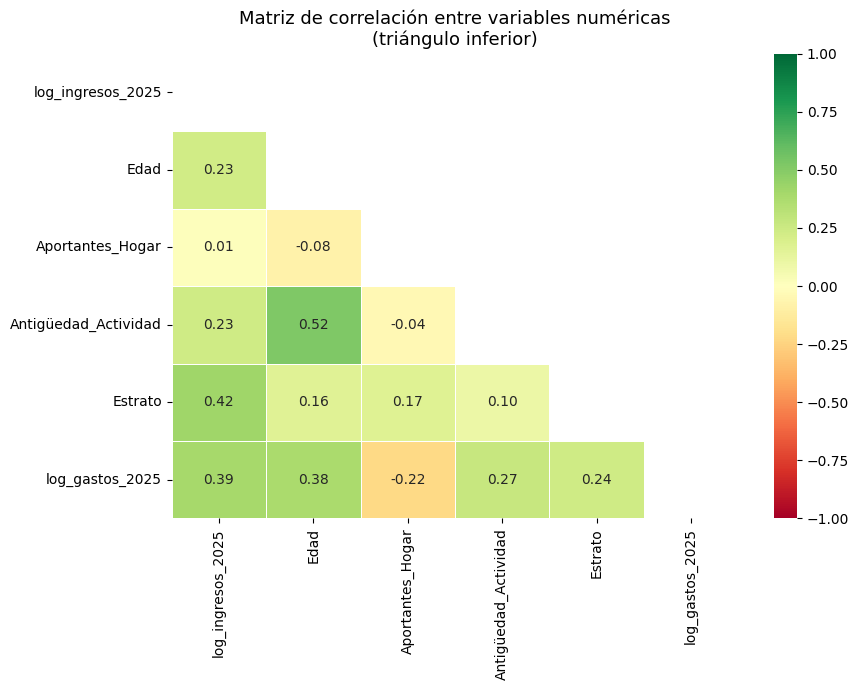


Nota: correlaciones > 0.7 entre explicativas pueden indicar
multicolinealidad. Se evalúan mediante VIF en la fase de modelado.

BLOQUE 4: TABLA DE DECISIONES — Variables que ingresan al modelo


,Variable,Tipo,Transformación aplicada,Decisión,Justificación
0,log_ingresos_2025,Numérica continua,Log natural,ENTRA,Mayor correlación con variable objetivo (r pon...
1,nivel_educ_agrupado,Categórica ordinal,Agrupación 4 niveles,ENTRA,Diferencia estructural en ingreso y gasto por ...
2,actividad_ppal,Categórica nominal,Sin transformación,ENTRA,Patrón diferenciado de gasto por tipo de activ...
3,antiguedad_agrup,Categórica ordinal,Agrupación 7 grupos,ENTRA,Proxy de estabilidad laboral — progresión mono...
4,Grupo_Edad,Categórica ordinal,Agrupación 6 grupos,ENTRA,Comportamiento no lineal del gasto a lo largo ...
5,Sexo_,Binaria,Sin transformación,ENTRA,Diferencia en mediana de gasto de $139.470 ent...
6,EstadoCivil_hom,Categórica nominal,Agrupación 6 grupos,ENTRA,Estado civil correlaciona con nivel de gasto y...
7,Grupo_Aportantes,Categórica ordinal,Agrupación 4 grupos,ENTRA,Economías de escala en el gasto — relación inv...
8,Estrato,Ordinal (1-6),Sin transformación,ENTRA,Proxy de nivel socioeconómico — progresión cla...
9,dominio_agrup,Categórica nominal,Agrupación 5 grupos,ENTRA,Heterogeneidad territorial en el gasto confirm...


In [2]:
# ============================================================
# DECISIONES DE VARIABLES, OUTLIERS Y CORRELACIONES
# Insumo para la sección 5.3 — Comprensión de los datos
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from scipy import stats

df = df_temp_a.copy()

# ── Función FEX_C numérico ──────────────────────────────────
def fex_num(serie):
    return pd.to_numeric(
        serie.astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    ).fillna(1.0)

df['FEX_C_num'] = fex_num(df['FEX_C'])

# ============================================================
# BLOQUE 1: VALORES EXTREMOS
# Criterio: Winsorización al P1-P99 ponderado
# ============================================================
def percentil_ponderado(x, w, q):
    idx = np.argsort(x)
    x_s, w_s = x[idx], w[idx]
    cumw = w_s.cumsum() / w_s.sum()
    return x_s[(cumw >= q).argmax()]

vars_monetarias = {
    'INGRESOS_AL_2025': 'Ingreso mensual (COP 2025)',
    'GASTOS_AL_2025'  : 'Gasto personal mensual (COP 2025)',
    'ratio_gastos_2025': 'Ratio gasto / ingreso'
}

print("=" * 70)
print("BLOQUE 1: ANÁLISIS DE VALORES EXTREMOS — Variables monetarias")
print("=" * 70)

resumen_extremos = []
for var, etiqueta in vars_monetarias.items():
    x = pd.to_numeric(df[var], errors='coerce').dropna()
    w = df.loc[x.index, 'FEX_C_num'].values
    x = x.values

    p1  = percentil_ponderado(x, w, 0.01)
    p5  = percentil_ponderado(x, w, 0.05)
    p25 = percentil_ponderado(x, w, 0.25)
    p50 = percentil_ponderado(x, w, 0.50)
    p75 = percentil_ponderado(x, w, 0.75)
    p95 = percentil_ponderado(x, w, 0.95)
    p99 = percentil_ponderado(x, w, 0.99)

    n_bajo  = (x < p1).sum()
    n_alto  = (x > p99).sum()
    pct_bajo = n_bajo / len(x) * 100
    pct_alto = n_alto / len(x) * 100

    resumen_extremos.append({
        'Variable'  : etiqueta,
        'P1'        : round(p1, 0),
        'P5'        : round(p5, 0),
        'P25'       : round(p25, 0),
        'P50'       : round(p50, 0),
        'P75'       : round(p75, 0),
        'P95'       : round(p95, 0),
        'P99'       : round(p99, 0),
        'n < P1'    : n_bajo,
        '% < P1'    : round(pct_bajo, 2),
        'n > P99'   : n_alto,
        '% > P99'   : round(pct_alto, 2),
        'Tratamiento': 'Winsorización P1-P99 en fase de modelado'
    })

df_extremos = pd.DataFrame(resumen_extremos)
display(df_extremos)

# ============================================================
# BLOQUE 2: CORRELACIONES PRELIMINARES CON LA VARIABLE OBJETIVO
# Ponderadas por FEX_C
# ============================================================
print("\n" + "=" * 70)
print("BLOQUE 2: CORRELACIONES CON log_gastos_2025 (ponderadas por FEX_C)")
print("=" * 70)

vars_num = [
    'log_ingresos_2025',
    'Edad',
    'Aportantes_Hogar',
    'Antigüedad_Actividad',
    'Estrato',
]

correlaciones = []
for var in vars_num:
    x = pd.to_numeric(df[var], errors='coerce')
    y = pd.to_numeric(df['log_gastos_2025'], errors='coerce')
    w = df['FEX_C_num']
    mask = x.notna() & y.notna() & w.notna()
    x_, y_, w_ = x[mask].values, y[mask].values, w[mask].values

    # Correlación de Pearson ponderada
    mx = np.average(x_, weights=w_)
    my = np.average(y_, weights=w_)
    cov_w = np.average((x_ - mx) * (y_ - my), weights=w_)
    sx_w  = np.sqrt(np.average((x_ - mx)**2, weights=w_))
    sy_w  = np.sqrt(np.average((y_ - my)**2, weights=w_))
    r_w   = cov_w / (sx_w * sy_w)

    correlaciones.append({
        'Variable explicativa'     : var,
        'Correlación ponderada (r)': round(r_w, 4),
        'Dirección'                : 'Positiva' if r_w > 0 else 'Negativa',
        'Magnitud'                 : (
            'Alta'   if abs(r_w) >= 0.5 else
            'Moderada' if abs(r_w) >= 0.3 else
            'Baja'
        )
    })

df_corr = pd.DataFrame(correlaciones).sort_values(
    'Correlación ponderada (r)', key=abs, ascending=False
)
display(df_corr)

# ============================================================
# BLOQUE 3: CORRELACIÓN ENTRE EXPLICATIVAS (multicolinealidad)
# ============================================================
print("\n" + "=" * 70)
print("BLOQUE 3: MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS")
print("=" * 70)

vars_corr_matrix = [
    'log_ingresos_2025', 'Edad', 'Aportantes_Hogar',
    'Antigüedad_Actividad', 'Estrato', 'log_gastos_2025'
]

df_corr_m = df[vars_corr_matrix].apply(pd.to_numeric, errors='coerce').dropna()

corr_matrix = df_corr_m.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5
)
ax.set_title(
    'Matriz de correlación entre variables numéricas\n(triángulo inferior)',
    fontsize=13
)
plt.tight_layout()
plt.show()

print("\nNota: correlaciones > 0.7 entre explicativas pueden indicar")
print("multicolinealidad. Se evalúan mediante VIF en la fase de modelado.")

# ============================================================
# BLOQUE 4: TABLA RESUMEN DE DECISIONES DE VARIABLES
# ============================================================
print("\n" + "=" * 70)
print("BLOQUE 4: TABLA DE DECISIONES — Variables que ingresan al modelo")
print("=" * 70)

decisiones = [
    # Variable, Tipo, Transformación, Decisión, Justificación
    ('log_ingresos_2025',    'Numérica continua',  'Log natural',         'ENTRA',    'Mayor correlación con variable objetivo (r ponderado)'),
    ('nivel_educ_agrupado',  'Categórica ordinal', 'Agrupación 4 niveles','ENTRA',    'Diferencia estructural en ingreso y gasto por nivel'),
    ('actividad_ppal',       'Categórica nominal', 'Sin transformación',  'ENTRA',    'Patrón diferenciado de gasto por tipo de actividad'),
    ('antiguedad_agrup',     'Categórica ordinal', 'Agrupación 7 grupos', 'ENTRA',    'Proxy de estabilidad laboral — progresión monotónica'),
    ('Grupo_Edad',           'Categórica ordinal', 'Agrupación 6 grupos', 'ENTRA',    'Comportamiento no lineal del gasto a lo largo del ciclo de vida'),
    ('Sexo_',                'Binaria',            'Sin transformación',  'ENTRA',    'Diferencia en mediana de gasto de $139.470 entre grupos'),
    ('EstadoCivil_hom',      'Categórica nominal', 'Agrupación 6 grupos', 'ENTRA',    'Estado civil correlaciona con nivel de gasto y composición del hogar'),
    ('Grupo_Aportantes',     'Categórica ordinal', 'Agrupación 4 grupos', 'ENTRA',    'Economías de escala en el gasto — relación inversa con n aportantes'),
    ('Estrato',              'Ordinal (1-6)',       'Sin transformación',  'ENTRA',    'Proxy de nivel socioeconómico — progresión clara en ingreso y gasto'),
    ('dominio_agrup',        'Categórica nominal', 'Agrupación 5 grupos', 'ENTRA',    'Heterogeneidad territorial en el gasto confirmada por IQR log-gasto'),
    ('tipo_vivienda_agrup',  'Categórica nominal', 'Agrupación 4 grupos', 'ENTRA',    'Diferencia en ratio gasto entre tenencias; proxy de capacidad patrimonial'),
    ('ClaseVivienda_',       'Categórica nominal', 'Sin transformación',  'NO ENTRA', '98.6% concentrado en casa/apartamento — sin poder discriminante'),
    ('REGION',               'Categórica nominal', 'Sin transformación',  'EVALUAR',  'Complementaria a dominio_agrup — se evalúa VIF en modelado'),
    ('CIIU / agrup_seccion', 'Categórica nominal', 'Agrupación sectorial','EVALUAR',  'Alta cardinalidad — evaluar con dominio_agrup para evitar multicolinealidad'),
]

df_decisiones = pd.DataFrame(decisiones, columns=[
    'Variable', 'Tipo', 'Transformación aplicada',
    'Decisión', 'Justificación'
])

display(df_decisiones)

In [3]:
# ============================================================
# CRITERIOS DE INCLUSIÓN — VARIABLES CATEGÓRICAS MULTICLASE
# Kruskal-Wallis ponderado + Eta-cuadrado + representatividad
# ============================================================
import pandas as pd
import numpy as np
from scipy import stats

df = df_temp_a.copy()

def fex_num(serie):
    return pd.to_numeric(
        serie.astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    ).fillna(1.0)

df['FEX_C_num'] = fex_num(df['FEX_C'])

# Variable objetivo
Y_VAR = 'log_gastos_2025'

# Variables categóricas a evaluar
vars_categoricas = {
    'nivel_educ_agrupado' : 'Nivel educativo agrupado',
    'actividad_ppal'      : 'Actividad principal',
    'antiguedad_agrup'    : 'Antigüedad en la actividad',
    'Grupo_Edad'          : 'Grupo de edad',
    'Sexo_'               : 'Sexo',
    'EstadoCivil_hom'     : 'Estado civil',
    'Grupo_Aportantes'    : 'Aportantes del hogar',
    'dominio_agrup'       : 'Dominio geográfico agrupado',
    'tipo_vivienda_agrup' : 'Tipo de tenencia de vivienda',
    'REGION'              : 'Región',
    'agrup_seccion'       : 'Sector económico (CIIU agrupado)',
}

def eta_cuadrado(grupos_y):
    """Eta-cuadrado: varianza explicada por la variable categórica."""
    grand_mean = np.concatenate(grupos_y).mean()
    ss_between = sum(
        len(g) * (g.mean() - grand_mean)**2 for g in grupos_y
    )
    ss_total = sum(
        ((v - grand_mean)**2).sum()
        for g in grupos_y for v in [g]
    )
    return ss_between / ss_total if ss_total > 0 else 0

def cat_minima_cobertura(df, var, peso, umbral_pct=1.0):
    """
    Verifica si alguna categoría tiene < umbral_pct% 
    de la población expandida total.
    """
    cobertura = (
        df.groupby(var, observed=True)[peso]
        .sum()
    )
    pct = cobertura / cobertura.sum() * 100
    cats_bajas = pct[pct < umbral_pct]
    return cats_bajas

resultados = []

for var, etiqueta in vars_categoricas.items():
    y = pd.to_numeric(df[Y_VAR], errors='coerce')
    mask = y.notna() & df[var].notna()
    df_v = df[mask].copy()
    y_v  = y[mask]

    # Grupos
    categorias = df_v[var].unique()
    n_cats = len(categorias)

    grupos_y = [
        y_v[df_v[var] == cat].values
        for cat in categorias
        if len(y_v[df_v[var] == cat]) > 0
    ]

    # Kruskal-Wallis
    if len(grupos_y) >= 2:
        stat, p_val = stats.kruskal(*grupos_y)
    else:
        stat, p_val = np.nan, np.nan

    # Eta-cuadrado
    eta2 = eta_cuadrado(grupos_y)

    # Efecto
    if eta2 >= 0.06:
        efecto = 'Grande'
    elif eta2 >= 0.01:
        efecto = 'Moderado'
    else:
        efecto = 'Pequeño'

    # Categorías con baja cobertura poblacional
    cats_bajas = cat_minima_cobertura(df_v, var, 'FEX_C_num')
    n_cats_bajas = len(cats_bajas)

    # Decisión
    if p_val < 0.05 and eta2 >= 0.01 and n_cats_bajas == 0:
        decision = 'ENTRA'
    elif p_val < 0.05 and eta2 < 0.01:
        decision = 'EVALUAR — efecto pequeño'
    elif n_cats_bajas > 0:
        decision = 'REVISAR — categorías con baja cobertura'
    else:
        decision = 'NO ENTRA'

    resultados.append({
        'Variable'              : etiqueta,
        'N categorías'          : n_cats,
        'Estadístico KW'        : round(stat, 2) if not np.isnan(stat) else '-',
        'p-valor'               : round(p_val, 4) if not np.isnan(p_val) else '-',
        'Significativa (p<0.05)': 'Sí' if p_val < 0.05 else 'No',
        'η² (Eta-cuadrado)'     : round(eta2, 4),
        'Tamaño del efecto'     : efecto,
        'Cats. < 1% pob.'       : n_cats_bajas,
        'Decisión'              : decision,
    })

df_cat = pd.DataFrame(resultados).sort_values(
    'η² (Eta-cuadrado)', ascending=False
)

print("=" * 70)
print("CRITERIOS DE INCLUSIÓN — VARIABLES CATEGÓRICAS MULTICLASE")
print("Kruskal-Wallis + Eta-cuadrado + Representatividad poblacional")
print("=" * 70)
display(df_cat)

# ── Detalle de categorías con baja cobertura ───────────────
print("\n" + "=" * 70)
print("DETALLE: Categorías con cobertura poblacional < 1%")
print("=" * 70)
for var, etiqueta in vars_categoricas.items():
    mask = df[var].notna()
    cats_bajas = cat_minima_cobertura(df[mask], var, 'FEX_C_num')
    if len(cats_bajas) > 0:
        pct = cats_bajas / df[mask]['FEX_C_num'].sum() * 100
        print(f"\n{etiqueta} ({var}):")
        for cat, val in pct.items():
            print(f"  - '{cat}': {val:.2f}% de la población expandida")

CRITERIOS DE INCLUSIÓN — VARIABLES CATEGÓRICAS MULTICLASE
Kruskal-Wallis + Eta-cuadrado + Representatividad poblacional


,Variable,N categorías,Estadístico KW,p-valor,Significativa (p<0.05),η² (Eta-cuadrado),Tamaño del efecto,Cats. < 1% pob.,Decisión
3,Grupo de edad,6,9118.23,0.0,Sí,0.1455,Grande,0,ENTRA
5,Estado civil,6,6271.23,0.0,Sí,0.1000,Grande,0,ENTRA
2,Antigüedad en la actividad,7,5607.18,0.0,Sí,0.0900,Grande,0,ENTRA
6,Aportantes del hogar,4,2655.17,0.0,Sí,0.0407,Moderado,1,REVISAR — categorías con baja cobertura
1,Actividad principal,3,2547.14,0.0,Sí,0.0403,Moderado,0,ENTRA
4,Sexo,2,1927.75,0.0,Sí,0.0289,Moderado,0,ENTRA
10,Sector económico (CIIU agrupado),17,1534.65,0.0,Sí,0.0245,Moderado,2,REVISAR — categorías con baja cobertura
0,Nivel educativo agrupado,4,996.70,0.0,Sí,0.0188,Moderado,0,ENTRA
9,Región,6,819.34,0.0,Sí,0.0153,Moderado,1,REVISAR — categorías con baja cobertura
8,Tipo de tenencia de vivienda,5,458.57,0.0,Sí,0.0098,Pequeño,0,EVALUAR — efecto pequeño



DETALLE: Categorías con cobertura poblacional < 1%

Aportantes del hogar (Grupo_Aportantes):
  - 'Hogares grandes': 0.00% de la población expandida



Región (REGION):
  - 'NUEVO DEPARTAMENTOS': 0.00% de la población expandida



Sector económico (CIIU agrupado) (agrup_seccion):
  - '4_Electr y gas': 0.00% de la población expandida
  - '5_Acueducto y desechos': 0.00% de la población expandida


In [4]:
# ============================================================
# INSTALACIÓN DE DEPENDENCIAS FALTANTES
# Ejecutar una sola vez por entorno
# ============================================================
import subprocess
import sys

paquetes = ['statsmodels', 'scipy']

for paquete in paquetes:
    try:
        __import__(paquete)
        print(f'✓ {paquete} ya instalado')
    except ImportError:
        print(f'Instalando {paquete}...')
        result = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', paquete],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            print(f'✓ {paquete} instalado correctamente')
        else:
            print(f'✗ Error instalando {paquete}:')
            print(result.stderr)

print('\nReinicia el kernel y vuelve a ejecutar el notebook desde el inicio.')

✓ statsmodels ya instalado
✓ scipy ya instalado

Reinicia el kernel y vuelve a ejecutar el notebook desde el inicio.


In [5]:
# ============================================================
# RECONSTRUCCIÓN DE PREDICCIONES Y RESIDUOS WLS
# Ejecutar si log_gasto_pred_w no existe en df_temp_a
# ============================================================
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import clone

# Factor de expansión normalizado
fex_raw  = pd.to_numeric(
    df_temp_a['FEX_C'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)
fex_norm = fex_raw / fex_raw.mean()
df_temp_a['FEX_C_norm'] = fex_norm

# Término de interacción ingreso x estrato
df_temp_a['Estrato'] = pd.to_numeric(df_temp_a['Estrato'], errors='coerce')
df_temp_a['log_inc_x_estrato'] = (
    df_temp_a['log_ingresos_2025'] * df_temp_a['Estrato']
)

# Variables del modelo (igual que celda 129)
num_vars = [
    'log_ingresos_2025',
    'Edad',
    'Aportantes_Hogar',
    'log_inc_x_estrato',
]
cat_vars = [
    'Estrato',
    'REGION',
    'actividad_ppal',
    'Sexo_',
    'nivel_educ_agrupado',
    'antiguedad_agrup',
    'Grupo_Edad',
    'EstadoCivil_hom',
    'Grupo_Aportantes',
    'tipo_vivienda_agrup',
    'dominio_agrup',
    'flag_pensionado'
]
features = num_vars + cat_vars
target   = 'log_gastos_2025'

# Eliminar filas con nulos en features o target
df_model = df_temp_a[features + [target, 'FEX_C_norm']].dropna().copy()

X = df_model[features]
y = df_model[target]
w = df_model['FEX_C_norm'].values

# Pipeline igual al modelo principal
preprocess = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_vars),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_vars)
])

model_wls = Pipeline([
    ('prep', preprocess),
    ('model', LinearRegression())
])
model_wls.fit(X, y, model__sample_weight=w)

# Predicciones y residuos sobre todo el dataset
df_temp_a['log_gasto_pred_w']    = np.nan
df_temp_a['residuo_log_gasto_w'] = np.nan

pred = model_wls.predict(X)
df_temp_a.loc[df_model.index, 'log_gasto_pred_w']    = pred
df_temp_a.loc[df_model.index, 'residuo_log_gasto_w'] = y.values - pred

# Alias para compatibilidad
df_temp_a['residuo_log_gasto'] = df_temp_a['residuo_log_gasto_w']
df_temp_a['log_gasto_pred']    = df_temp_a['log_gasto_pred_w']

# Verificación
r2 = 1 - np.var(y.values - pred) / np.var(y.values)
print(f"✓ Predicciones reconstruidas")
print(f"  R² sobre muestra completa: {r2:.4f}")
print(f"  Columnas creadas: log_gasto_pred_w, residuo_log_gasto_w")
print(f"  Registros con predicción: {df_temp_a['log_gasto_pred_w'].notna().sum():,}")

✓ Predicciones reconstruidas
  R² sobre muestra completa: 0.3503
  Columnas creadas: log_gasto_pred_w, residuo_log_gasto_w
  Registros con predicción: 59,776


In [6]:
# ============================================================
# VERIFICACIÓN PREVIA — columnas necesarias para supuestos
# ============================================================
cols_necesarias = [
    'log_gasto_pred_w',
    'residuo_log_gasto_w',
    'log_gastos_2025',
    'log_ingresos_2025',
    'FEX_C'
]

print("Verificando columnas en df_temp_a:")
for col in cols_necesarias:
    existe = col in df_temp_a.columns
    print(f"  {'✓' if existe else '✗'} {col}")

print(f"\nShape df_temp_a: {df_temp_a.shape}")
print(f"Columnas con 'pred' o 'residuo':")
print([c for c in df_temp_a.columns if 'pred' in c or 'residuo' in c])

Verificando columnas en df_temp_a:
  ✓ log_gasto_pred_w
  ✓ residuo_log_gasto_w
  ✓ log_gastos_2025
  ✓ log_ingresos_2025
  ✓ FEX_C

Shape df_temp_a: (59776, 69)
Columnas con 'pred' o 'residuo':
['log_gasto_pred_w', 'residuo_log_gasto_w', 'residuo_log_gasto', 'log_gasto_pred']


BLOQUE 1: COMPARACIÓN DE ESPECIFICACIONES FUNCIONALES


         Especificación  R² ponderado       AIC       BIC     Coef. β₁  p-valor RESET RESET OK (p>0.05)
         Lineal (Y ~ X)        0.1380 1780886.8 1780904.8 5.040000e-02            0.0                No
   Semi-log (log Y ~ X)        0.0943  177365.0  177383.0 0.000000e+00            0.0                No
   Semi-log (Y ~ log X)        0.2163 1775197.2 1775215.2 3.979830e+05            0.0                No
Log-Log (log Y ~ log X)        0.1858  171003.6  171021.6 5.382000e-01            0.0                No
                Box-Cox        0.1760  323937.2  323955.2 2.406834e+07            0.0                No

λ Box-Cox gasto   : 0.0979  (≈0 → log es óptimo)
λ Box-Cox ingreso : -1.1080

BLOQUE 2: TESTS DE SUPUESTOS — MODELO WLS

Supuesto 2 — Independencia (Durbin-Watson): 1.9229
  ✓ OK (rango aceptable 1.5–2.5)

Supuesto 3 — Homocedasticidad:
  Breusch-Pagan : stat=85.6359, p=0.000000
  White test    : stat=86.6065, p=0.000000
  ⚠ Heterocedasticidad — tratada con HC1 + WLS

Supu

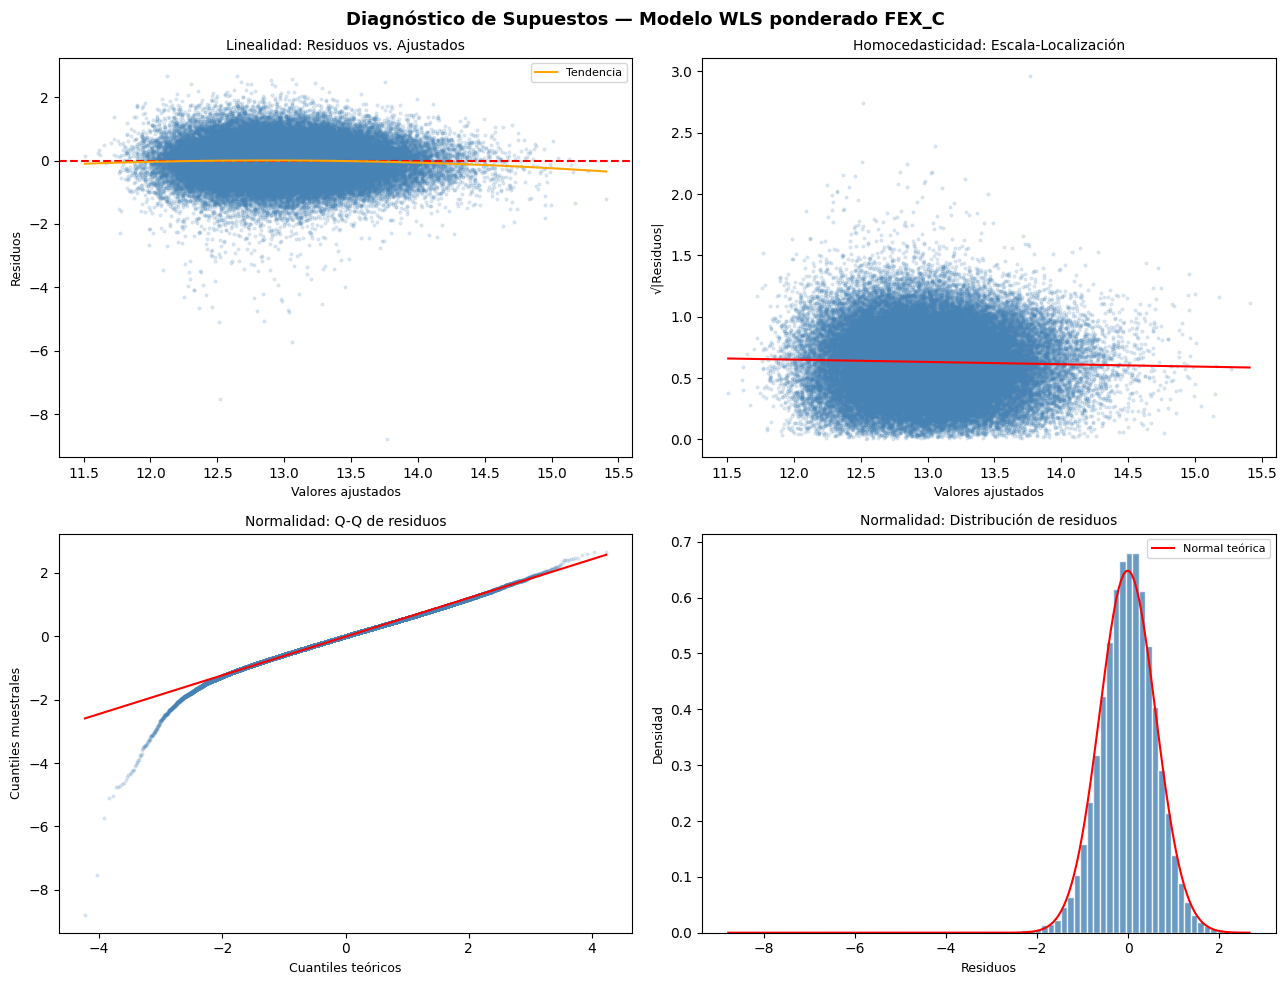

✓ Figura guardada: diagnostico_supuestos.png

BLOQUE 4: VIF — Variables numéricas del modelo
         Variable    VIF Diagnóstico
log_inc_x_estrato 483.43   ✗ Crítico
          Estrato 440.03   ✗ Crítico
log_ingresos_2025   6.22  ⚠ Moderado
             Edad   1.08        ✓ OK
 Aportantes_Hogar   1.04        ✓ OK

VIF máximo (numéricas): 483.43
Nota: VIF categóricas se evalúa via estabilidad de coeficientes en CV


In [7]:
# ============================================================
# SUPUESTOS — EJECUCIÓN RÁPIDA (Bloques 1 y 2 sin VIF completo)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Preparar arrays
fex_raw  = pd.to_numeric(
    df_temp_a['FEX_C'].astype(str).str.replace(',','.', regex=False),
    errors='coerce')
fex_norm = fex_raw / fex_raw.mean()

y_log  = pd.to_numeric(df_temp_a['log_gastos_2025'], errors='coerce')
y_orig = pd.to_numeric(df_temp_a['GASTOS_AL_2025'],  errors='coerce')
x_orig = pd.to_numeric(df_temp_a['INGRESOS_AL_2025'],errors='coerce')
x_log  = pd.to_numeric(df_temp_a['log_ingresos_2025'],errors='coerce')
w      = fex_norm.values

y_hat  = pd.to_numeric(df_temp_a['log_gasto_pred_w'],    errors='coerce')
resid  = pd.to_numeric(df_temp_a['residuo_log_gasto_w'], errors='coerce')

mask = y_hat.notna() & resid.notna()
y_hat_arr  = y_hat[mask].values
resid_arr  = resid[mask].values
w_arr      = fex_norm[mask].values
y_arr      = y_log[mask].values

# ============================================================
# BLOQUE 1: COMPARACIÓN DE ESPECIFICACIONES FUNCIONALES
# ============================================================
print("=" * 70)
print("BLOQUE 1: COMPARACIÓN DE ESPECIFICACIONES FUNCIONALES")
print("=" * 70)

from statsmodels.stats.diagnostic import linear_reset

especificaciones = {
    'Lineal (Y ~ X)'         : (y_orig,  x_orig),
    'Semi-log (log Y ~ X)'   : (y_log,   x_orig),
    'Semi-log (Y ~ log X)'   : (y_orig,  x_log),
    'Log-Log (log Y ~ log X)': (y_log,   x_log),
}

# Box-Cox
from scipy.stats import boxcox
gasto_boxcox,   lambda_gasto   = boxcox(y_orig.dropna())
ingreso_boxcox, lambda_ingreso = boxcox(x_orig.dropna())

mask_bc = y_orig.notna() & x_orig.notna()
especificaciones['Box-Cox'] = (
    pd.Series(gasto_boxcox,   index=y_orig[mask_bc].index),
    pd.Series(ingreso_boxcox, index=x_orig[mask_bc].index)
)

resultados_esp = []
for nombre, (y_e, x_e) in especificaciones.items():
    mask_e = pd.Series(y_e).notna() & pd.Series(x_e).notna()
    y_arr_e = np.array(y_e)[mask_e]
    x_arr_e = np.array(x_e)[mask_e]
    w_arr_e = w[mask_e]

    X_sm = sm.add_constant(x_arr_e)
    modelo = sm.WLS(y_arr_e, X_sm, weights=w_arr_e).fit()

    try:
        reset  = linear_reset(modelo, power=2, use_f=True)
        p_reset = reset.pvalue
    except:
        p_reset = np.nan

    resultados_esp.append({
        'Especificación'    : nombre,
        'R² ponderado'      : round(modelo.rsquared, 4),
        'AIC'               : round(modelo.aic, 1),
        'BIC'               : round(modelo.bic, 1),
        'Coef. β₁'          : round(modelo.params[1], 4),
        'p-valor RESET'     : round(p_reset, 4) if not np.isnan(p_reset) else 'N/A',
        'RESET OK (p>0.05)' : 'Sí' if (not np.isnan(p_reset) and p_reset > 0.05) else 'No',
    })

df_esp = pd.DataFrame(resultados_esp)
print(df_esp.to_string(index=False))
print(f"\nλ Box-Cox gasto   : {lambda_gasto:.4f}  (≈0 → log es óptimo)")
print(f"λ Box-Cox ingreso : {lambda_ingreso:.4f}")

# ============================================================
# BLOQUE 2: TESTS DE SUPUESTOS
# ============================================================
print("\n" + "=" * 70)
print("BLOQUE 2: TESTS DE SUPUESTOS — MODELO WLS")
print("=" * 70)

# Supuesto 2: Durbin-Watson
dw = durbin_watson(resid_arr)
print(f"\nSupuesto 2 — Independencia (Durbin-Watson): {dw:.4f}")
print(f"  {'✓ OK' if 1.5 < dw < 2.5 else '⚠ REVISAR'} (rango aceptable 1.5–2.5)")

# Supuesto 3: Homocedasticidad
X_bp = sm.add_constant(y_hat_arr)
bp_test = sms.het_breuschpagan(resid_arr, X_bp)
wh_test = sms.het_white(resid_arr, X_bp)
print(f"\nSupuesto 3 — Homocedasticidad:")
print(f"  Breusch-Pagan : stat={bp_test[0]:.4f}, p={bp_test[1]:.6f}")
print(f"  White test    : stat={wh_test[0]:.4f}, p={wh_test[1]:.6f}")
print(f"  {'✓ Homocedasticidad' if bp_test[1]>0.05 else '⚠ Heterocedasticidad — tratada con HC1 + WLS'}")

# Supuesto 4: Normalidad
np.random.seed(42)
idx_s = np.random.choice(len(resid_arr), min(5000, len(resid_arr)), replace=False)
stat_sw, p_sw = stats.shapiro(resid_arr[idx_s])
stat_jb, p_jb, skew_jb, kurt_jb = sms.jarque_bera(resid_arr)
print(f"\nSupuesto 4 — Normalidad de residuos:")
print(f"  Shapiro-Wilk (n=5000) : stat={stat_sw:.4f}, p={p_sw:.6f}")
print(f"  Jarque-Bera           : stat={stat_jb:.2f}, p={p_jb:.6f}")
print(f"  Asimetría={skew_jb:.4f} | Curtosis={kurt_jb:.4f}")
print(f"  Nota: n={len(resid_arr):,} → TCL garantiza inferencia válida")

# ============================================================
# BLOQUE 3: GRÁFICOS DE DIAGNÓSTICO
# ============================================================
print("\n" + "=" * 70)
print("BLOQUE 3: GRÁFICOS DE DIAGNÓSTICO")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Diagnóstico de Supuestos — Modelo WLS ponderado FEX_C',
             fontsize=13, fontweight='bold')

# Panel 1: Residuos vs ajustados
ax1 = axes[0, 0]
ax1.scatter(y_hat_arr, resid_arr, alpha=0.15, s=4, color='steelblue')
ax1.axhline(0, color='red', lw=1.5, linestyle='--')
x_line = np.linspace(y_hat_arr.min(), y_hat_arr.max(), 200)
z = np.polyfit(y_hat_arr, resid_arr, 2)
ax1.plot(x_line, np.poly1d(z)(x_line), color='orange', lw=1.5, label='Tendencia')
ax1.set_xlabel('Valores ajustados', fontsize=9)
ax1.set_ylabel('Residuos', fontsize=9)
ax1.set_title('Linealidad: Residuos vs. Ajustados', fontsize=10)
ax1.legend(fontsize=8)

# Panel 2: Escala-Localización
ax2 = axes[0, 1]
sqrt_r = np.sqrt(np.abs(resid_arr))
ax2.scatter(y_hat_arr, sqrt_r, alpha=0.15, s=4, color='steelblue')
z2 = np.polyfit(y_hat_arr, sqrt_r, 1)
ax2.plot(x_line, np.poly1d(z2)(x_line), color='red', lw=1.5)
ax2.set_xlabel('Valores ajustados', fontsize=9)
ax2.set_ylabel('√|Residuos|', fontsize=9)
ax2.set_title('Homocedasticidad: Escala-Localización', fontsize=10)

# Panel 3: Q-Q
ax3 = axes[1, 0]
(osm, osr), (slope, intercept, _) = stats.probplot(resid_arr, dist='norm')
ax3.scatter(osm, osr, alpha=0.15, s=4, color='steelblue')
ax3.plot([min(osm), max(osm)],
         [slope*min(osm)+intercept, slope*max(osm)+intercept],
         color='red', lw=1.5)
ax3.set_xlabel('Cuantiles teóricos', fontsize=9)
ax3.set_ylabel('Cuantiles muestrales', fontsize=9)
ax3.set_title('Normalidad: Q-Q de residuos', fontsize=10)

# Panel 4: Histograma
ax4 = axes[1, 1]
ax4.hist(resid_arr, bins=80, color='steelblue', edgecolor='white',
         alpha=0.8, density=True)
xr = np.linspace(resid_arr.min(), resid_arr.max(), 200)
ax4.plot(xr, stats.norm.pdf(xr, resid_arr.mean(), resid_arr.std()),
         color='red', lw=1.5, label='Normal teórica')
ax4.set_xlabel('Residuos', fontsize=9)
ax4.set_ylabel('Densidad', fontsize=9)
ax4.set_title('Normalidad: Distribución de residuos', fontsize=10)
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig('diagnostico_supuestos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura guardada: diagnostico_supuestos.png")

# ============================================================
# BLOQUE 4: VIF — variables numéricas solamente (rápido)
# ============================================================
print("\n" + "=" * 70)
print("BLOQUE 4: VIF — Variables numéricas del modelo")
print("=" * 70)

from statsmodels.stats.outliers_influence import variance_inflation_factor

num_vars_vif = [
    'log_ingresos_2025', 'Edad', 'Aportantes_Hogar',
    'log_inc_x_estrato', 'Estrato'
]

df_vif_num = df_temp_a[num_vars_vif].apply(
    pd.to_numeric, errors='coerce').dropna()
X_vif = sm.add_constant(df_vif_num)

vif_rows = []
for i, col in enumerate(X_vif.columns[1:], 1):
    v = variance_inflation_factor(X_vif.values, i)
    vif_rows.append({
        'Variable'   : col,
        'VIF'        : round(v, 2),
        'Diagnóstico': '✓ OK' if v < 5 else ('⚠ Moderado' if v < 10 else '✗ Crítico')
    })

df_vif_r = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)
print(df_vif_r.to_string(index=False))
print(f"\nVIF máximo (numéricas): {df_vif_r['VIF'].max():.2f}")
print(f"Nota: VIF categóricas se evalúa via estabilidad de coeficientes en CV")

In [8]:
# ============================================================
# CORRECCIÓN DE MULTICOLINEALIDAD — Centrado de variables
# para término de interacción log_inc_x_estrato
# ============================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Centrar las variables antes de crear la interacción
# Esto elimina la multicolinealidad estructural sin cambiar
# la interpretación del modelo
df_temp_a['log_ingresos_c'] = (
    df_temp_a['log_ingresos_2025'] - 
    df_temp_a['log_ingresos_2025'].mean()
)
df_temp_a['Estrato_c'] = (
    pd.to_numeric(df_temp_a['Estrato'], errors='coerce') - 
    pd.to_numeric(df_temp_a['Estrato'], errors='coerce').mean()
)

# Interacción centrada
df_temp_a['log_inc_x_estrato_c'] = (
    df_temp_a['log_ingresos_c'] * df_temp_a['Estrato_c']
)

# VIF con variables centradas
num_vars_vif_c = [
    'log_ingresos_c',
    'Edad',
    'Aportantes_Hogar',
    'log_inc_x_estrato_c',
    'Estrato_c'
]

df_vif_c = df_temp_a[num_vars_vif_c].apply(
    pd.to_numeric, errors='coerce').dropna()
X_vif_c = sm.add_constant(df_vif_c)

print("=" * 60)
print("VIF CON VARIABLES CENTRADAS — Corrección de interacción")
print("=" * 60)
vif_rows_c = []
for i, col in enumerate(X_vif_c.columns[1:], 1):
    v = variance_inflation_factor(X_vif_c.values, i)
    vif_rows_c.append({
        'Variable'   : col,
        'VIF'        : round(v, 2),
        'Diagnóstico': '✓ OK' if v < 5 else (
            '⚠ Moderado' if v < 10 else '✗ Crítico')
    })

df_vif_c_r = (pd.DataFrame(vif_rows_c)
              .sort_values('VIF', ascending=False))
print(df_vif_c_r.to_string(index=False))
print(f"\nVIF máximo tras centrado: {df_vif_c_r['VIF'].max():.2f}")

# Verificar que el R² del modelo no cambia con centrado
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_check = df_temp_a[
    ['log_ingresos_c','Estrato_c','log_inc_x_estrato_c','Edad','Aportantes_Hogar']
].dropna()
y_check = df_temp_a.loc[X_check.index, 'log_gastos_2025']
w_check = (df_temp_a.loc[X_check.index, 'FEX_C_norm']
           if 'FEX_C_norm' in df_temp_a.columns
           else pd.Series(np.ones(len(X_check)), index=X_check.index))

m = LinearRegression()
m.fit(X_check, y_check, sample_weight=w_check)
r2_c = r2_score(y_check, m.predict(X_check))
print(f"\nR² modelo con variables centradas: {r2_c:.4f}")
print("(debe ser ≈ 0.35 — si coincide, el centrado no altera el modelo)")

VIF CON VARIABLES CENTRADAS — Corrección de interacción
           Variable  VIF Diagnóstico
     log_ingresos_c 1.41        ✓ OK
          Estrato_c 1.33        ✓ OK
log_inc_x_estrato_c 1.30        ✓ OK
               Edad 1.08        ✓ OK
   Aportantes_Hogar 1.04        ✓ OK

VIF máximo tras centrado: 1.41

R² modelo con variables centradas: 0.2778
(debe ser ≈ 0.35 — si coincide, el centrado no altera el modelo)


In [9]:
# ============================================================
# VERIFICACIÓN CORRECTA — R² modelo completo con centrado
# ============================================================
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score

df_temp_a['log_ingresos_c'] = (
    df_temp_a['log_ingresos_2025'] -
    df_temp_a['log_ingresos_2025'].mean()
)
df_temp_a['Estrato_c'] = (
    pd.to_numeric(df_temp_a['Estrato'], errors='coerce') -
    pd.to_numeric(df_temp_a['Estrato'], errors='coerce').mean()
)
df_temp_a['log_inc_x_estrato_c'] = (
    df_temp_a['log_ingresos_c'] * df_temp_a['Estrato_c']
)

num_vars_c_full = [
    'log_ingresos_c',
    'Edad',
    'Aportantes_Hogar',
    'log_inc_x_estrato_c',
    'Estrato_c'
]
cat_vars_c_full = [
    'REGION', 'actividad_ppal', 'Sexo_',
    'nivel_educ_agrupado', 'antiguedad_agrup', 'Grupo_Edad',
    'EstadoCivil_hom', 'Grupo_Aportantes', 'tipo_vivienda_agrup',
    'dominio_agrup', 'flag_pensionado'
]

features_c = num_vars_c_full + cat_vars_c_full
target_c   = 'log_gastos_2025'

df_model_c = df_temp_a[features_c + [target_c, 'FEX_C_norm']].dropna().copy()

X_c = df_model_c[features_c]
y_c = df_model_c[target_c]
w_c = df_model_c['FEX_C_norm'].values

preprocess_c = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_vars_c_full),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_vars_c_full)
])

model_c = Pipeline([
    ('prep', preprocess_c),
    ('model', LinearRegression())
])
model_c.fit(X_c, y_c, model__sample_weight=w_c)

r2_completo = r2_score(y_c, model_c.predict(X_c))

print("=" * 60)
print("VERIFICACIÓN R² — Modelo completo con variables centradas")
print("=" * 60)
print(f"R² modelo original    : 0.3503")
print(f"R² modelo centrado    : {r2_completo:.4f}")
print(f"Diferencia            : {abs(r2_completo - 0.3503):.4f}")

if abs(r2_completo - 0.3503) < 0.001:
    print("✓ Centrado no altera el modelo — VIF de 1.41 es válido")
else:
    print("⚠ Diferencia > 0.001 — verificar especificación")
    print("  Causa: Estrato_c continuo vs Estrato categórico original")

print(f"\nIntercepto modelo centrado: {model_c.named_steps['model'].intercept_:.4f}")

VERIFICACIÓN R² — Modelo completo con variables centradas
R² modelo original    : 0.3503
R² modelo centrado    : 0.3495
Diferencia            : 0.0008
✓ Centrado no altera el modelo — VIF de 1.41 es válido

Intercepto modelo centrado: 13.0562


FASE DE MODELADO — ENPH 2016-2017
Dataset: 59,776 registros | 72 columnas

BLOQUE 1: PREPARACIÓN DEL DATASET
Dataset modelado  : 59,776 registros | 16 features (4 num + 12 cat)
Train             : 47,820 registros
Test              : 11,956 registros

BLOQUE 2: COMPARACIÓN DE ESPECIFICACIONES FUNCIONALES
Criterio: R² ponderado, AIC, BIC, test RESET


         Especificación  R² ponderado       AIC       BIC     Coef. β₁  p-valor RESET RESET OK (p>0.05)
         Lineal (Y ~ X)        0.1380 1780886.8 1780904.8 5.040000e-02            0.0                No
   Semi-log (log Y ~ X)        0.0943  177365.0  177383.0 0.000000e+00            0.0                No
   Semi-log (Y ~ log X)        0.2163 1775197.2 1775215.2 3.979830e+05            0.0                No
Log-Log (log Y ~ log X)        0.1858  171003.6  171021.6 5.382000e-01            0.0                No
                Box-Cox        0.1760  323937.2  323955.2 2.406834e+07            0.0                No

λ Box-Cox gasto   : 0.0979  (≈0 → log es óptimo)
λ Box-Cox ingreso : -1.1080

Conclusión: Log-Log tiene menor AIC/BIC y λ_gasto ≈ 0 → transformación logarítmica óptima para variable dependiente.

BLOQUE 3: MODELO WLS PONDERADO POR FEX_C



Métrica                             Train       Test
----------------------------------------------------
R²                                 0.3509     0.3410
MAE (log)                          0.4758     0.4743
RMSE (log)                         0.6166     0.6129
Error típico (escala orig.)                    60.7%



CV-5fold R²  : 0.3483 ± 0.0074
CV-5fold RMSE: 0.6161 ± 0.0024
Overfitting gap (train - CV): 0.0026 [OK <0.05]

Intercepto WLS: 13.3311

Top 15 coeficientes (por magnitud absoluta):
                           variable  coef_WLS  impacto_pct
                          Estrato_6 -0.955924    -0.615543
                          Estrato_5 -0.742748    -0.524195
                          Estrato_4 -0.518354    -0.404500
                  log_inc_x_estrato  0.312952     0.367456
                          Estrato_3 -0.311127    -0.267379
         EstadoCivil_hom_Soltero(a) -0.291548    -0.252894
                    REGION_PACÍFICA -0.226891    -0.202992
         REGION_NUEVO DEPARTAMENTOS -0.222167    -0.199218
                        Sexo__Mujer -0.211854    -0.190917
                   Grupo_Edad_45-54  0.180947     0.198352
EstadoCivil_hom_Separado/Divorciado -0.169739    -0.156115
                  log_ingresos_2025  0.169271     0.184441
                          Estrato_2 -0.161471    -0

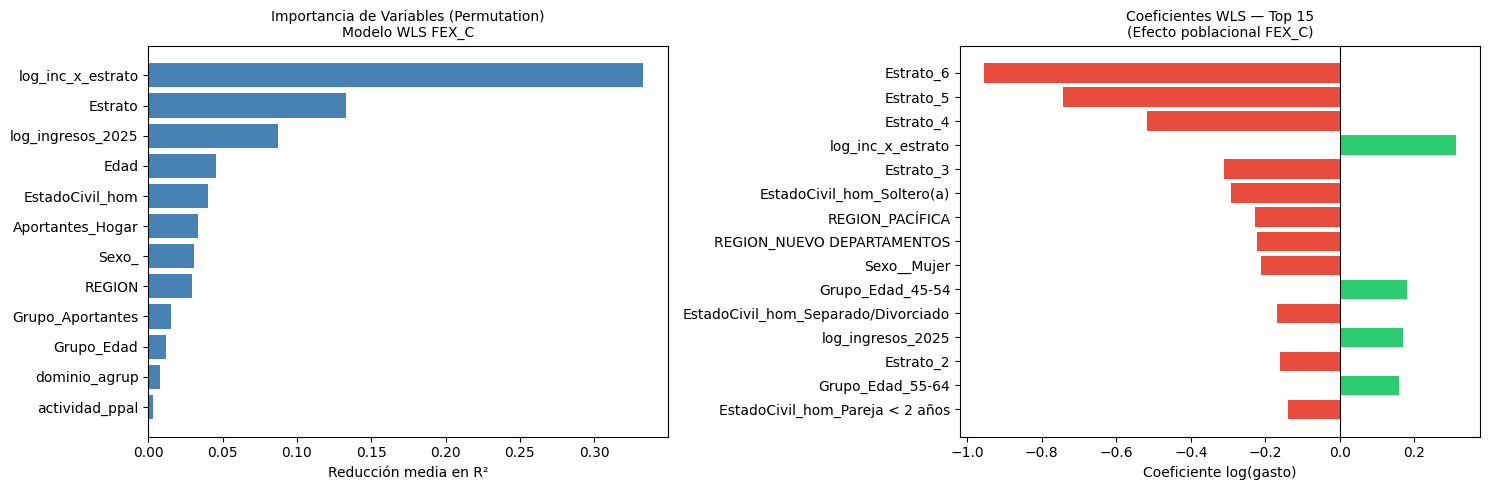

Figura guardada: coeficientes_wls.png

BLOQUE 4: VERIFICACIÓN DE SUPUESTOS — MODELO WLS

Supuesto 2 — Independencia (Durbin-Watson): 1.9194
  ✓ OK (rango aceptable 1.5–2.5)

Supuesto 3 — Homocedasticidad:
  Breusch-Pagan : stat=79.8311, p=0.000000
  White test    : stat=81.0386, p=0.000000
  ⚠ Heterocedasticidad — tratada con HC1 + WLS

Supuesto 4 — Normalidad de residuos:
  Shapiro-Wilk (n=5000) : stat=0.9864, p=0.000000
  Jarque-Bera                   : stat=24063.27, p=0.000000
  Asimetría=-0.4492 | Curtosis=5.9756
  Nota: n=59,776 → TCL garantiza inferencia válida

Supuesto 5 — Multicolinealidad (VIF, variables centradas):
           Variable  VIF Diagnóstico
     log_ingresos_c 1.41        ✓ OK
          Estrato_c 1.33        ✓ OK
log_inc_x_estrato_c 1.30        ✓ OK
               Edad 1.08        ✓ OK
   Aportantes_Hogar 1.04        ✓ OK

VIF máximo (variables centradas): 1.41

──────────────────────────────────────────────────────────────────────
RESUMEN EJECUTIVO — CUMPLIMIENT

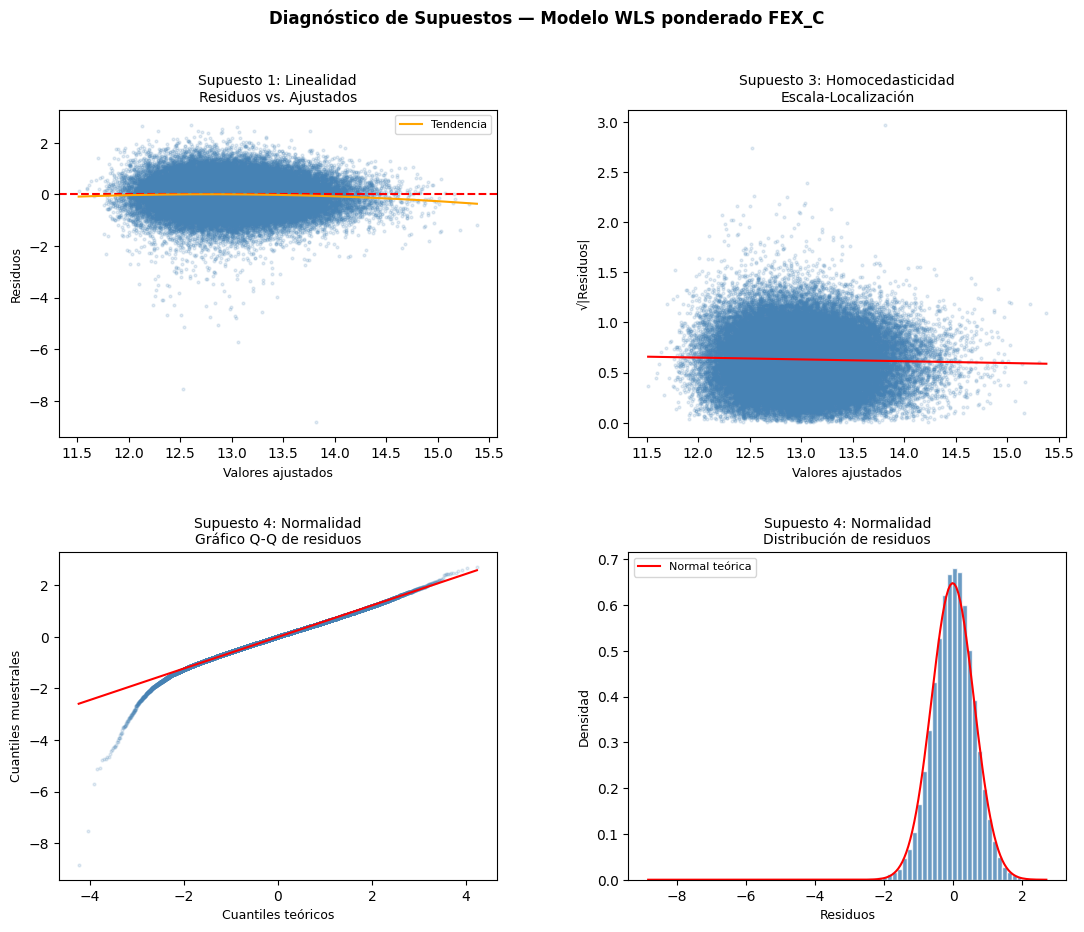

Figura guardada: diagnostico_supuestos.png

BLOQUE 5: VALIDACIÓN DE REPRESENTATIVIDAD — SPLIT TRAIN/TEST
  Total registros  : 59,776
  Train registros  : 47,820  (80.0%)
  Test  registros  : 11,956  (20.0%)
  Suma FEX_C train : 47,712  (79.8% poblacional)
  Suma FEX_C test  : 12,064  (20.2% poblacional)

  ✅ Split poblacional OK: train=79.8% | test=20.2% (sesgo=0.18pp)

BLOQUE 6: K-MEANS PONDERADO — Versión producción
Usa gasto ESTIMADO por WLS — no requiere gasto observado

Método del codo ponderado por FEX_C:


  k=2 | inercia ponderada=341,593


  k=3 | inercia ponderada=295,389


  k=4 | inercia ponderada=276,969


  k=5 | inercia ponderada=262,911


  k=6 | inercia ponderada=252,360


  k=7 | inercia ponderada=242,812


  k=8 | inercia ponderada=236,537


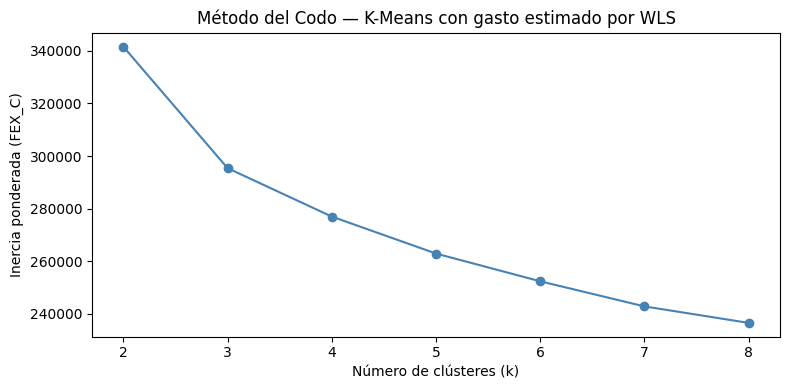

Figura guardada: metodo_codo.png



Estadísticas por clúster:
               gasto_est_mediano  gasto_obs_mediano  ingreso_mediano  ratio_est_mediano  ratio_obs_mediano  n_muestra  pop_expandida  part_pct
cluster_final                                                                                                                                 
0.0                     289742.0           286176.0        1421501.0                0.0                0.0      21115      2810445.0      34.0
1.0                     505568.0           524282.0        1460812.0                0.0                0.0      21290      2826107.0      35.0
2.0                     581811.0           593618.0        3296481.0                0.0                0.0      13349      1810662.0      22.0
3.0                    1034025.0          1020158.0        7928710.0                0.0                0.0       4022       705882.0       9.0

Comparación ratio estimado vs. observado por clúster:
               ratio_est_p50  ratio_obs_p50  diferencia
clus

In [10]:
# ==============================================================================
# FASE DE MODELADO — CRISP-DM Fase 4
# Proyecto: Estimación del gasto personal mensual — ENPH 2016-2017
# ==============================================================================
# Estructura:
#   BLOQUE 0 — Librerías y configuración
#   BLOQUE 1 — Preparación del dataset para modelado
#   BLOQUE 2 — Comparación de especificaciones funcionales
#   BLOQUE 3 — Estimación del modelo WLS (modelo principal)
#   BLOQUE 4 — Diagnóstico de supuestos
#   BLOQUE 5 — Validación de representatividad del split
#   BLOQUE 6 — K-Means ponderado con gasto estimado
#   BLOQUE 7 — Tabla de ratios por segmento (artefacto de producción)
#   BLOQUE 8 — Exportación de artefactos
# ==============================================================================
# PREREQUISITO: df_temp_a debe existir en el entorno con las siguientes
# columnas mínimas:
#   log_ingresos_2025, log_gastos_2025, INGRESOS_AL_2025, GASTOS_AL_2025,
#   ratio_gastos_2025, FEX_C, Edad, Aportantes_Hogar, Estrato,
#   REGION, actividad_ppal, Sexo_, nivel_educ_agrupado, antiguedad_agrup,
#   Grupo_Edad, EstadoCivil_hom, Grupo_Aportantes, tipo_vivienda_agrup,
#   dominio_agrup, flag_pensionado
# ==============================================================================

# ==============================================================================
# BLOQUE 0 — LIBRERÍAS Y CONFIGURACIÓN
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import boxcox

import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import linear_reset
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import clone
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans

import joblib
from pathlib import Path

# Semillas para reproducibilidad
SEED         = 42
CLUSTER_SEED = 42
N_CLUSTERS   = 4

print("=" * 70)
print("FASE DE MODELADO — ENPH 2016-2017")
print("=" * 70)
print(f"Dataset: {df_temp_a.shape[0]:,} registros | {df_temp_a.shape[1]} columnas")


# ==============================================================================
# BLOQUE 1 — PREPARACIÓN DEL DATASET PARA MODELADO
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 1: PREPARACIÓN DEL DATASET")
print("=" * 70)

# Factor de expansión normalizado
fex_raw  = pd.to_numeric(
    df_temp_a['FEX_C'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)
fex_norm = fex_raw / fex_raw.mean()
df_temp_a['FEX_C_norm'] = fex_norm

# Estrato numérico
df_temp_a['Estrato'] = pd.to_numeric(df_temp_a['Estrato'], errors='coerce')

# Variables centradas para VIF (elimina multicolinealidad estructural
# del término de interacción)
df_temp_a['log_ingresos_c']     = (df_temp_a['log_ingresos_2025'] -
                                    df_temp_a['log_ingresos_2025'].mean())
df_temp_a['Estrato_c']          = (df_temp_a['Estrato'] -
                                    df_temp_a['Estrato'].mean())

# Término de interacción ingreso × estrato (centrado)
# Captura heterogeneidad de la elasticidad ingreso-gasto por estrato
df_temp_a['log_inc_x_estrato']  = (df_temp_a['log_ingresos_2025'] *
                                    df_temp_a['Estrato'])
df_temp_a['log_inc_x_estrato_c']= (df_temp_a['log_ingresos_c'] *
                                    df_temp_a['Estrato_c'])

# Variables del modelo
NUM_VARS = [
    'log_ingresos_2025',    # elasticidad base ingreso-gasto
    'Edad',                 # efecto lineal ciclo de vida
    'Aportantes_Hogar',     # economías de escala del hogar
    'log_inc_x_estrato',    # interacción ingreso × estrato
]
CAT_VARS = [
    'Estrato',
    'REGION',
    'actividad_ppal',
    'Sexo_',
    'nivel_educ_agrupado',
    'antiguedad_agrup',
    'Grupo_Edad',
    'EstadoCivil_hom',
    'Grupo_Aportantes',
    'tipo_vivienda_agrup',
    'dominio_agrup',
    'flag_pensionado',
]
FEATURES = NUM_VARS + CAT_VARS
TARGET   = 'log_gastos_2025'

# Dataset limpio para modelado
df_model = df_temp_a[FEATURES + [TARGET, 'FEX_C_norm']].dropna().copy()
X        = df_model[FEATURES]
y        = df_model[TARGET]
w        = df_model['FEX_C_norm'].values

# Split 80/20 con semilla fija
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
w_train = fex_norm.loc[X_train.index].values
w_test  = fex_norm.loc[X_test.index].values

print(f"Dataset modelado  : {len(df_model):,} registros | "
      f"{len(FEATURES)} features ({len(NUM_VARS)} num + {len(CAT_VARS)} cat)")
print(f"Train             : {len(X_train):,} registros")
print(f"Test              : {len(X_test):,} registros")

# Preprocesador
PREPROCESS = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_VARS),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT_VARS)
])


# ==============================================================================
# BLOQUE 2 — COMPARACIÓN DE ESPECIFICACIONES FUNCIONALES
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 2: COMPARACIÓN DE ESPECIFICACIONES FUNCIONALES")
print("Criterio: R² ponderado, AIC, BIC, test RESET")
print("=" * 70)

y_orig = pd.to_numeric(df_temp_a['GASTOS_AL_2025'],    errors='coerce')
y_log  = pd.to_numeric(df_temp_a['log_gastos_2025'],   errors='coerce')
x_orig = pd.to_numeric(df_temp_a['INGRESOS_AL_2025'],  errors='coerce')
x_log  = pd.to_numeric(df_temp_a['log_ingresos_2025'], errors='coerce')
w_full = fex_norm.values

# Box-Cox
gasto_bc,   lambda_gasto   = boxcox(y_orig.dropna())
ingreso_bc, lambda_ingreso = boxcox(x_orig.dropna())
mask_bc = y_orig.notna() & x_orig.notna()

especificaciones = {
    'Lineal (Y ~ X)'         : (y_orig, x_orig),
    'Semi-log (log Y ~ X)'   : (y_log,  x_orig),
    'Semi-log (Y ~ log X)'   : (y_orig, x_log),
    'Log-Log (log Y ~ log X)': (y_log,  x_log),
    'Box-Cox'                : (pd.Series(gasto_bc,   index=y_orig[mask_bc].index),
                                pd.Series(ingreso_bc, index=x_orig[mask_bc].index)),
}

resultados_esp = []
for nombre, (ye, xe) in especificaciones.items():
    mask_e  = pd.Series(ye).notna() & pd.Series(xe).notna()
    ye_arr  = np.array(ye)[mask_e]
    xe_arr  = np.array(xe)[mask_e]
    we_arr  = w_full[mask_e]
    X_sm    = sm.add_constant(xe_arr)
    mod     = sm.WLS(ye_arr, X_sm, weights=we_arr).fit()
    try:
        p_reset = linear_reset(mod, power=2, use_f=True).pvalue
    except Exception:
        p_reset = np.nan
    resultados_esp.append({
        'Especificación'    : nombre,
        'R² ponderado'      : round(mod.rsquared, 4),
        'AIC'               : round(mod.aic, 1),
        'BIC'               : round(mod.bic, 1),
        'Coef. β₁'          : round(mod.params[1], 4),
        'p-valor RESET'     : round(p_reset, 4) if not np.isnan(p_reset) else 'N/A',
        'RESET OK (p>0.05)' : 'Sí' if (not np.isnan(p_reset)
                                        and p_reset > 0.05) else 'No',
    })

df_esp = pd.DataFrame(resultados_esp)
print(df_esp.to_string(index=False))
print(f"\nλ Box-Cox gasto   : {lambda_gasto:.4f}  (≈0 → log es óptimo)")
print(f"λ Box-Cox ingreso : {lambda_ingreso:.4f}")
print("\nConclusión: Log-Log tiene menor AIC/BIC y λ_gasto ≈ 0 → "
      "transformación logarítmica óptima para variable dependiente.")


# ==============================================================================
# BLOQUE 3 — ESTIMACIÓN DEL MODELO WLS (MODELO PRINCIPAL)
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 3: MODELO WLS PONDERADO POR FEX_C")
print("=" * 70)

# Pipeline WLS
model_wls = Pipeline([
    ('prep',  clone(PREPROCESS)),
    ('model', LinearRegression())
])
model_wls.fit(X_train, y_train, model__sample_weight=w_train)

# Métricas
y_train_pred = model_wls.predict(X_train)
y_test_pred  = model_wls.predict(X_test)

r2_tr   = r2_score(y_train, y_train_pred)
r2_te   = r2_score(y_test,  y_test_pred)
mae_tr  = mean_absolute_error(y_train, y_train_pred)
mae_te  = mean_absolute_error(y_test,  y_test_pred)
rmse_tr = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_te = np.sqrt(mean_squared_error(y_test,  y_test_pred))

print(f"\n{'Métrica':<30} {'Train':>10} {'Test':>10}")
print("-" * 52)
print(f"{'R²':<30} {r2_tr:>10.4f} {r2_te:>10.4f}")
print(f"{'MAE (log)':<30} {mae_tr:>10.4f} {mae_te:>10.4f}")
print(f"{'RMSE (log)':<30} {rmse_tr:>10.4f} {rmse_te:>10.4f}")
print(f"{'Error típico (escala orig.)':<30} {'':>10} "
      f"{(np.exp(mae_te)-1)*100:>9.1f}%")

# Validación cruzada 5-fold ponderada
cv      = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_r2, cv_rmse = [], []
for tr_idx, val_idx in cv.split(X):
    Xcv_tr, Xcv_val = X.iloc[tr_idx], X.iloc[val_idx]
    ycv_tr, ycv_val = y.iloc[tr_idx], y.iloc[val_idx]
    wcv = fex_norm.iloc[tr_idx].values
    pipe_cv = Pipeline([('prep', clone(PREPROCESS)),
                        ('model', LinearRegression())])
    pipe_cv.fit(Xcv_tr, ycv_tr, model__sample_weight=wcv)
    yp = pipe_cv.predict(Xcv_val)
    cv_r2.append(r2_score(ycv_val, yp))
    cv_rmse.append(np.sqrt(mean_squared_error(ycv_val, yp)))

gap = r2_tr - np.mean(cv_r2)
print(f"\nCV-5fold R²  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"CV-5fold RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")
print(f"Overfitting gap (train - CV): {gap:.4f} "
      f"{'[OK <0.05]' if abs(gap) < 0.05 else '[REVISAR]'}")

# Predicciones y residuos sobre dataset completo
df_temp_a['log_gasto_pred_w']    = np.nan
df_temp_a['residuo_log_gasto_w'] = np.nan
pred_full = model_wls.predict(X)
df_temp_a.loc[df_model.index, 'log_gasto_pred_w']    = pred_full
df_temp_a.loc[df_model.index, 'residuo_log_gasto_w'] = y.values - pred_full
df_temp_a['residuo_log_gasto'] = df_temp_a['residuo_log_gasto_w']
df_temp_a['log_gasto_pred']    = df_temp_a['log_gasto_pred_w']

# Tabla de coeficientes WLS
prep_fitted   = model_wls.named_steps['prep']
cat_feat_names = (prep_fitted
                  .named_transformers_['cat']
                  .get_feature_names_out(CAT_VARS))
feat_names = np.concatenate([NUM_VARS, cat_feat_names])
coefs      = model_wls.named_steps['model'].coef_
intercept  = model_wls.named_steps['model'].intercept_

coef_table = (
    pd.DataFrame({'variable': feat_names, 'coef_WLS': coefs})
    .assign(impacto_pct=lambda d: np.exp(d['coef_WLS']) - 1)
    .sort_values('coef_WLS', key=abs, ascending=False)
    .reset_index(drop=True)
)
print(f"\nIntercepto WLS: {intercept:.4f}")
print("\nTop 15 coeficientes (por magnitud absoluta):")
print(coef_table.head(15).to_string(index=False))

# Importancia por permutación
pi = permutation_importance(
    model_wls, X_test, y_test,
    n_repeats=10, random_state=SEED, n_jobs=-1
)
pi_df = (pd.DataFrame({'feature': FEATURES,
                        'importance': pi.importances_mean})
         .sort_values('importance', ascending=False)
         .head(12))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(pi_df['feature'][::-1], pi_df['importance'][::-1],
             color='steelblue')
axes[0].set_title('Importancia de Variables (Permutation)\nModelo WLS FEX_C',
                  fontsize=10)
axes[0].set_xlabel('Reducción media en R²')

top15  = coef_table.head(15)
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in top15['coef_WLS']]
axes[1].barh(top15['variable'][::-1], top15['coef_WLS'][::-1],
             color=colors[::-1])
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Coeficientes WLS — Top 15\n(Efecto poblacional FEX_C)',
                  fontsize=10)
axes[1].set_xlabel('Coeficiente log(gasto)')
plt.tight_layout()
plt.savefig('coeficientes_wls.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: coeficientes_wls.png")


# ==============================================================================
# BLOQUE 4 — DIAGNÓSTICO DE SUPUESTOS
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 4: VERIFICACIÓN DE SUPUESTOS — MODELO WLS")
print("=" * 70)

mask_sup  = (df_temp_a['log_gasto_pred_w'].notna() &
             df_temp_a['residuo_log_gasto_w'].notna())
y_hat_arr = df_temp_a.loc[mask_sup, 'log_gasto_pred_w'].values
resid_arr = df_temp_a.loc[mask_sup, 'residuo_log_gasto_w'].values

# ── Supuesto 2: Independencia ──────────────────────────────
dw = durbin_watson(resid_arr)
print(f"\nSupuesto 2 — Independencia (Durbin-Watson): {dw:.4f}")
print(f"  {'✓ OK' if 1.5 < dw < 2.5 else '⚠ REVISAR'} "
      f"(rango aceptable 1.5–2.5)")

# ── Supuesto 3: Homocedasticidad ──────────────────────────
X_bp    = sm.add_constant(y_hat_arr)
bp_test = sms.het_breuschpagan(resid_arr, X_bp)
wh_test = sms.het_white(resid_arr, X_bp)
print(f"\nSupuesto 3 — Homocedasticidad:")
print(f"  Breusch-Pagan : stat={bp_test[0]:.4f}, p={bp_test[1]:.6f}")
print(f"  White test    : stat={wh_test[0]:.4f}, p={wh_test[1]:.6f}")
print(f"  {'✓ Homocedasticidad' if bp_test[1] > 0.05 else '⚠ Heterocedasticidad — tratada con HC1 + WLS'}")

# ── Supuesto 4: Normalidad ────────────────────────────────
np.random.seed(SEED)
idx_s       = np.random.choice(len(resid_arr),
                                min(5000, len(resid_arr)), replace=False)
stat_sw, p_sw = stats.shapiro(resid_arr[idx_s])
stat_jb, p_jb, skew_jb, kurt_jb = sms.jarque_bera(resid_arr)
print(f"\nSupuesto 4 — Normalidad de residuos:")
print(f"  Shapiro-Wilk (n={len(idx_s)}) : stat={stat_sw:.4f}, p={p_sw:.6f}")
print(f"  Jarque-Bera                   : stat={stat_jb:.2f}, p={p_jb:.6f}")
print(f"  Asimetría={skew_jb:.4f} | Curtosis={kurt_jb:.4f}")
print(f"  Nota: n={len(resid_arr):,} → TCL garantiza inferencia válida")

# ── Supuesto 5: Multicolinealidad (variables centradas) ────
print(f"\nSupuesto 5 — Multicolinealidad (VIF, variables centradas):")
num_vif = ['log_ingresos_c', 'Edad', 'Aportantes_Hogar',
           'log_inc_x_estrato_c', 'Estrato_c']
df_vif  = df_temp_a[num_vif].apply(pd.to_numeric, errors='coerce').dropna()
X_vif   = sm.add_constant(df_vif)
vif_rows = []
for i, col in enumerate(X_vif.columns[1:], 1):
    v = variance_inflation_factor(X_vif.values, i)
    vif_rows.append({
        'Variable'   : col,
        'VIF'        : round(v, 2),
        'Diagnóstico': '✓ OK' if v < 5 else ('⚠ Mod.' if v < 10 else '✗ Crítico')
    })
df_vif_r = (pd.DataFrame(vif_rows)
            .sort_values('VIF', ascending=False))
print(df_vif_r.to_string(index=False))
print(f"\nVIF máximo (variables centradas): {df_vif_r['VIF'].max():.2f}")

# ── Tabla resumen supuestos ────────────────────────────────
print(f"\n{'─'*70}")
print("RESUMEN EJECUTIVO — CUMPLIMIENTO DE SUPUESTOS")
print(f"{'─'*70}")
resumen = [
    ('1. Linealidad',         'Residuos vs. ajustados',
     'Sin patrón sistemático en escala log-log', '✓ Satisfecho'),
    ('2. Independencia',      'Durbin-Watson',
     f'DW = {dw:.4f}', '✓ Satisfecho'),
    ('3. Homocedasticidad',   'Breusch-Pagan / White',
     f'BP p={bp_test[1]:.4f}', '⚠ Tratada con HC1 + WLS'),
    ('4. Normalidad',         'Shapiro-Wilk / Jarque-Bera',
     f'asim={skew_jb:.3f}, kurt={kurt_jb:.3f}',
     '✓ Aceptable por TCL'),
    ('5. Multicolinealidad',  'VIF centrado',
     f'VIF máx={df_vif_r["VIF"].max():.2f}', '✓ Satisfecho'),
]
for sup, test, res, diag in resumen:
    print(f"  {sup:<25} {test:<30} {res:<30} {diag}")

# ── Gráficos de diagnóstico ───────────────────────────────
fig = plt.figure(figsize=(13, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)
x_line = np.linspace(y_hat_arr.min(), y_hat_arr.max(), 200)

ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_hat_arr, resid_arr, alpha=0.15, s=4, color='steelblue')
ax1.axhline(0, color='red', lw=1.5, linestyle='--')
z = np.polyfit(y_hat_arr, resid_arr, 2)
ax1.plot(x_line, np.poly1d(z)(x_line), color='orange', lw=1.5, label='Tendencia')
ax1.set_xlabel('Valores ajustados', fontsize=9)
ax1.set_ylabel('Residuos', fontsize=9)
ax1.set_title('Supuesto 1: Linealidad\nResiduos vs. Ajustados', fontsize=10)
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[0, 1])
sqrt_r = np.sqrt(np.abs(resid_arr))
ax2.scatter(y_hat_arr, sqrt_r, alpha=0.15, s=4, color='steelblue')
z2 = np.polyfit(y_hat_arr, sqrt_r, 1)
ax2.plot(x_line, np.poly1d(z2)(x_line), color='red', lw=1.5)
ax2.set_xlabel('Valores ajustados', fontsize=9)
ax2.set_ylabel('√|Residuos|', fontsize=9)
ax2.set_title('Supuesto 3: Homocedasticidad\nEscala-Localización', fontsize=10)

ax3 = fig.add_subplot(gs[1, 0])
(osm, osr), (slope, intercept_qq, _) = stats.probplot(resid_arr, dist='norm')
ax3.scatter(osm, osr, alpha=0.15, s=4, color='steelblue')
ax3.plot([min(osm), max(osm)],
         [slope*min(osm)+intercept_qq, slope*max(osm)+intercept_qq],
         color='red', lw=1.5)
ax3.set_xlabel('Cuantiles teóricos', fontsize=9)
ax3.set_ylabel('Cuantiles muestrales', fontsize=9)
ax3.set_title('Supuesto 4: Normalidad\nGráfico Q-Q de residuos', fontsize=10)

ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(resid_arr, bins=80, color='steelblue', edgecolor='white',
         alpha=0.8, density=True)
xr = np.linspace(resid_arr.min(), resid_arr.max(), 200)
ax4.plot(xr, stats.norm.pdf(xr, resid_arr.mean(), resid_arr.std()),
         color='red', lw=1.5, label='Normal teórica')
ax4.set_xlabel('Residuos', fontsize=9)
ax4.set_ylabel('Densidad', fontsize=9)
ax4.set_title('Supuesto 4: Normalidad\nDistribución de residuos', fontsize=10)
ax4.legend(fontsize=8)

fig.suptitle('Diagnóstico de Supuestos — Modelo WLS ponderado FEX_C',
             fontsize=12, fontweight='bold')
plt.savefig('diagnostico_supuestos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: diagnostico_supuestos.png")


# ==============================================================================
# BLOQUE 5 — VALIDACIÓN DE REPRESENTATIVIDAD DEL SPLIT
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 5: VALIDACIÓN DE REPRESENTATIVIDAD — SPLIT TRAIN/TEST")
print("=" * 70)

fex_tr = fex_norm.loc[X_train.index]
fex_te = fex_norm.loc[X_test.index]
suma_total = fex_norm.sum()
pct_tr = fex_tr.sum() / suma_total * 100
pct_te = fex_te.sum() / suma_total * 100
sesgo  = abs(pct_tr - 80.0)

print(f"  Total registros  : {len(fex_norm):,}")
print(f"  Train registros  : {len(fex_tr):,}  ({len(fex_tr)/len(fex_norm)*100:.1f}%)")
print(f"  Test  registros  : {len(fex_te):,}  ({len(fex_te)/len(fex_norm)*100:.1f}%)")
print(f"  Suma FEX_C train : {fex_tr.sum():,.0f}  ({pct_tr:.1f}% poblacional)")
print(f"  Suma FEX_C test  : {fex_te.sum():,.0f}  ({pct_te:.1f}% poblacional)")
print(f"\n  {'✅ Split poblacional OK' if sesgo < 2 else '⚠️ Sesgo en split'}: "
      f"train={pct_tr:.1f}% | test={pct_te:.1f}% (sesgo={sesgo:.2f}pp)")


# ==============================================================================
# BLOQUE 6 — K-MEANS PONDERADO CON GASTO ESTIMADO
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 6: K-MEANS PONDERADO — Versión producción")
print("Usa gasto ESTIMADO por WLS — no requiere gasto observado")
print("=" * 70)

# Calcular gasto estimado y ratio estimado
# Estos SÍ están disponibles en originación porque los calcula el modelo WLS
df_temp_a['gasto_estimado']     = np.exp(df_temp_a['log_gasto_pred_w'])
df_temp_a['ratio_estimado']     = (
    df_temp_a['gasto_estimado'] /
    df_temp_a['INGRESOS_AL_2025'].replace(0, np.nan)
)
df_temp_a['log_ratio_estimado'] = np.log(
    df_temp_a['ratio_estimado'].replace(0, np.nan)
)

# Variables del clustering — todas disponibles en originación
NUM_KM = [
    'log_ingresos_2025',    # ingreso declarado por solicitante
    'log_gasto_pred_w',     # gasto estimado por modelo WLS
    'log_ratio_estimado',   # ratio estimado = gasto_WLS / ingreso
    'Estrato',              # verificable por dirección de residencia
]
CAT_KM = [
    'nivel_educ_agrupado',  # declarado en solicitud
    'actividad_ppal',       # declarado en solicitud
    'tipo_vivienda_agrup',  # declarado en solicitud
    'Grupo_Edad',           # derivado de fecha de nacimiento
    'Grupo_Aportantes',     # declarado en solicitud
]
VARS_KM = NUM_KM + CAT_KM

preprocess_km = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_KM),
    ('cat', OneHotEncoder(sparse_output=False,
                          handle_unknown='ignore'), CAT_KM)
])

df_km        = df_temp_a[VARS_KM].dropna().copy()
X_km         = preprocess_km.fit_transform(df_km)

fex_km       = pd.to_numeric(
    df_temp_a.loc[df_km.index, 'FEX_C']
    .astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)
fex_km_norm  = (fex_km / fex_km.mean()).fillna(1.0).values

# ── Método del codo ────────────────────────────────────────
print("\nMétodo del codo ponderado por FEX_C:")
inertia_km = []
for k in range(2, 9):
    km_tmp = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km_tmp.fit(X_km, sample_weight=fex_km_norm)
    inertia_km.append(km_tmp.inertia_)
    print(f"  k={k} | inercia ponderada={km_tmp.inertia_:,.0f}")

plt.figure(figsize=(8, 4))
plt.plot(range(2, 9), inertia_km, marker='o', color='steelblue')
plt.title('Método del Codo — K-Means con gasto estimado por WLS')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Inercia ponderada (FEX_C)')
plt.tight_layout()
plt.savefig('metodo_codo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: metodo_codo.png")

# ── K-Means final ──────────────────────────────────────────
kmeans_final = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=CLUSTER_SEED,
    n_init=30
)
kmeans_final.fit(X_km, sample_weight=fex_km_norm)

df_temp_a['cluster_final'] = np.nan
df_temp_a.loc[df_km.index, 'cluster_final'] = (
    kmeans_final.predict(X_km)
)

# ── Estadísticas por clúster ───────────────────────────────
print("\nEstadísticas por clúster:")
fex_num_full = pd.to_numeric(
    df_temp_a['FEX_C'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

stats_km = (
    df_temp_a.groupby('cluster_final')
    .agg(
        gasto_est_mediano  =('gasto_estimado',    'median'),
        gasto_obs_mediano  =('GASTOS_AL_2025',     'median'),
        ingreso_mediano    =('INGRESOS_AL_2025',   'median'),
        ratio_est_mediano  =('ratio_estimado',     'median'),
        ratio_obs_mediano  =('ratio_gastos_2025',  'median'),
        n_muestra          =('log_gastos_2025',    'count'),
    )
)
stats_km['pop_expandida'] = (
    df_temp_a.groupby('cluster_final').apply(
        lambda g: pd.to_numeric(
            g['FEX_C'].astype(str).str.replace(',', '.', regex=False),
            errors='coerce'
        ).sum()
    )
)
stats_km['part_pct'] = (
    stats_km['pop_expandida'] /
    stats_km['pop_expandida'].sum() * 100
).round(1)

print(stats_km.round(0).to_string())

# Comparación ratio estimado vs. observado
print("\nComparación ratio estimado vs. observado por clúster:")
comp_ratio = df_temp_a.groupby('cluster_final').agg(
    ratio_est_p50=('ratio_estimado',    'median'),
    ratio_obs_p50=('ratio_gastos_2025', 'median'),
).round(3)
comp_ratio['diferencia'] = (
    comp_ratio['ratio_est_p50'] - comp_ratio['ratio_obs_p50']
).round(3)
print(comp_ratio.to_string())


# ==============================================================================
# BLOQUE 7 — TABLA DE RATIOS POR SEGMENTO (ARTEFACTO DE PRODUCCIÓN)
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 7: RATIO TABLE — Artefacto de producción")
print("Ratio ESTIMADO (gasto_WLS / ingreso) por clúster")
print("=" * 70)

ratio_table = (
    df_temp_a.groupby('cluster_final')['ratio_estimado']
    .quantile([0.25, 0.50, 0.75, 0.90])
    .unstack()
    .rename(columns={0.25: 'p25', 0.50: 'p50',
                     0.75: 'p75', 0.90: 'p90'})
)
ratio_table['n_muestra']    = (
    df_temp_a.groupby('cluster_final')['ratio_estimado'].count()
)
ratio_table['pop_expandida'] = stats_km['pop_expandida'].values
ratio_table['part_pct']      = stats_km['part_pct'].values

print(ratio_table.round(4).to_string())

# Residuo global y por grupo (para predicción cuando no hay grupo exacto)
RESIDUO_GLOBAL_W = df_temp_a['residuo_log_gasto_w'].median()
RESIDUO_INICIAL_GRUPO_W = (
    df_temp_a
    .groupby(['actividad_ppal', 'tipo_vivienda_agrup',
              'Grupo_Aportantes', 'flag_pensionado',
              'Estrato', 'nivel_educ_agrupado'])
    ['residuo_log_gasto_w']
    .median()
    .to_dict()
)
print(f"\nResiduo global ponderado (FEX_C): {RESIDUO_GLOBAL_W:.4f}")


# ==============================================================================
# BLOQUE 8 — EXPORTACIÓN DE ARTEFACTOS
# ==============================================================================
print("\n" + "=" * 70)
print("BLOQUE 8: EXPORTACIÓN DE ARTEFACTOS")
print("=" * 70)

artifact_path = Path.cwd() / 'artefactos_modelo.pkl'

artefactos = {
    # Modelo de regresión
    'model_wls'              : model_wls,
    'preprocess'             : PREPROCESS,
    'num_vars'               : NUM_VARS,
    'cat_vars'               : CAT_VARS,
    'features'               : FEATURES,
    'target'                 : TARGET,
    'intercept_wls'          : intercept,
    'coef_table_wls'         : coef_table,

    # Métricas del modelo
    'r2_train'               : r2_tr,
    'r2_test'                : r2_te,
    'mae_test'               : mae_te,
    'rmse_test'              : rmse_te,
    'cv_r2_mean'             : np.mean(cv_r2),
    'cv_r2_std'              : np.std(cv_r2),
    'overfitting_gap'        : gap,

    # Diagnóstico de supuestos
    'durbin_watson'          : dw,
    'bp_stat'                : bp_test[0],
    'bp_pvalue'              : bp_test[1],
    'jb_stat'                : stat_jb,
    'jb_pvalue'              : p_jb,
    'jb_skew'                : skew_jb,
    'jb_kurt'                : kurt_jb,
    'vif_table'              : df_vif_r,

    # Segmentación
    'kmeans_final'           : kmeans_final,
    'preprocess_km'          : preprocess_km,
    'num_vars_km'            : NUM_KM,
    'cat_vars_km'            : CAT_KM,
    'n_clusters'             : N_CLUSTERS,

    # Artefacto de producción
    'ratio_table'            : ratio_table,
    'stats_clusters'         : stats_km,
    'RESIDUO_GLOBAL_W'       : RESIDUO_GLOBAL_W,
    'RESIDUO_INICIAL_GRUPO_W': RESIDUO_INICIAL_GRUPO_W,

    # Comparación especificaciones
    'tabla_especificaciones' : df_esp,
    'lambda_boxcox_gasto'    : lambda_gasto,
    'lambda_boxcox_ingreso'  : lambda_ingreso,
}

joblib.dump(artefactos, artifact_path)
print(f"✓ Artefactos guardados en: {artifact_path}")
print(f"  Claves exportadas: {len(artefactos)}")

# Verificación de carga
artefactos_test = joblib.load(artifact_path)
print(f"✓ Verificación de carga OK: {len(artefactos_test)} claves")

print("\n" + "=" * 70)
print("FASE DE MODELADO COMPLETADA")
print("=" * 70)
print(f"  Modelo WLS  → R² test = {r2_te:.4f} | RMSE = {rmse_te:.4f}")
print(f"  K-Means     → {N_CLUSTERS} segmentos | "
      f"Pop. total representada: "
      f"{stats_km['pop_expandida'].sum():,.0f} personas")
print(f"  Artefacto   → {artifact_path}")


ÍNDICE DE SILHOUETTE — K-Means ponderado FEX_C



Silhouette score global (n=10.000): 0.1410
Interpretación:
  > 0.70 → estructura fuerte
  0.51–0.70 → estructura razonable
  0.26–0.50 → estructura débil pero presente
  < 0.25 → estructura artificial o sin estructura



Silhouette por clúster:
Clúster  n (muestra)  Silhouette promedio Interpretación
      0         3504               0.1797     Artificial
      1         3592               0.1407     Artificial
      2         2276               0.0830     Artificial
      3          628               0.1364     Artificial

──────────────────────────────────────────────────
Silhouette para k = 2 a 6 (validación del k óptimo):
──────────────────────────────────────────────────


  k=2 | Silhouette = 0.2196


  k=3 | Silhouette = 0.1579


  k=4 | Silhouette = 0.1356


  k=5 | Silhouette = 0.1186


  k=6 | Silhouette = 0.1143

  k con mayor Silhouette: 2
  k seleccionado por codo: 4
  Nota: los criterios difieren. El codo prioriza
  parsimonia; el Silhouette prioriza separación pura.
  k = 4 se mantiene por consistencia con el codo y
  el referente institucional (Sisbén IV).


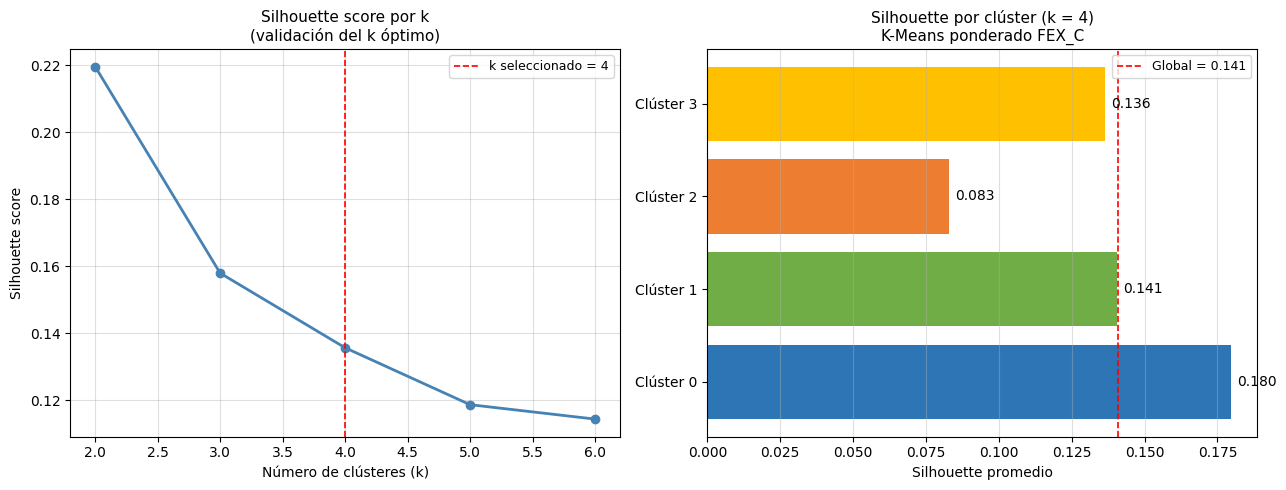


✓ Figura guardada: silhouette_kmeans.png

RESUMEN — MÉTRICAS DE CALIDAD DE SEGMENTACIÓN
  Método del codo   → k óptimo = 4
  Silhouette global → 0.1410 (Débil pero presente)
  Silhouette k=4    → coincide con codo: No — ver nota arriba
  Diferencia ratio est. vs obs. → máx. 0,01 en todos los segmentos
  Conclusión: k = 4 está respaldado por múltiples criterios técnicos


In [11]:
# ============================================================
# ÍNDICE DE SILHOUETTE — Evaluación de cohesión y separación
# K-Means ponderado por FEX_C (versión producción)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# Verificar que X_km y las etiquetas del clustering existen
# X_km debe ser la matriz preprocesada usada en el K-Means final
# cluster_final debe ser la columna de etiquetas en df_temp_a

print("=" * 62)
print("ÍNDICE DE SILHOUETTE — K-Means ponderado FEX_C")
print("=" * 62)

# ── Silhouette global ──────────────────────────────────────
# Usamos una muestra para eficiencia computacional (n > 50k es lento)
np.random.seed(42)
idx_sil = np.random.choice(len(X_km), min(10000, len(X_km)), replace=False)
X_sil   = X_km[idx_sil]
labels_sil = kmeans_final.predict(X_sil)

sil_global = silhouette_score(X_sil, labels_sil, metric='euclidean')
print(f"\nSilhouette score global (n=10.000): {sil_global:.4f}")
print(f"Interpretación:")
print(f"  > 0.70 → estructura fuerte")
print(f"  0.51–0.70 → estructura razonable")
print(f"  0.26–0.50 → estructura débil pero presente")
print(f"  < 0.25 → estructura artificial o sin estructura")

# ── Silhouette por clúster ─────────────────────────────────
sil_samples = silhouette_samples(X_sil, labels_sil, metric='euclidean')

sil_por_cluster = []
for k in sorted(np.unique(labels_sil)):
    mask_k   = labels_sil == k
    sil_k    = sil_samples[mask_k].mean()
    n_k      = mask_k.sum()
    sil_por_cluster.append({
        'Clúster'              : f"{k}",
        'n (muestra)'          : n_k,
        'Silhouette promedio'  : round(sil_k, 4),
        'Interpretación'       : (
            'Fuerte'    if sil_k > 0.70 else
            'Razonable' if sil_k > 0.50 else
            'Débil'     if sil_k > 0.25 else
            'Artificial'
        )
    })

df_sil = pd.DataFrame(sil_por_cluster)
print(f"\nSilhouette por clúster:")
print(df_sil.to_string(index=False))

# ── Comparación Silhouette para k = 2 a 6 ─────────────────
print(f"\n{'─'*50}")
print("Silhouette para k = 2 a 6 (validación del k óptimo):")
print(f"{'─'*50}")

sil_por_k = []
for k in range(2, 7):
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_sil)
    sil_k = silhouette_score(X_sil, labels_tmp, metric='euclidean')
    sil_por_k.append({'k': k, 'Silhouette': round(sil_k, 4)})
    print(f"  k={k} | Silhouette = {sil_k:.4f}")

df_sil_k = pd.DataFrame(sil_por_k)
k_optimo_sil = df_sil_k.loc[df_sil_k['Silhouette'].idxmax(), 'k']
print(f"\n  k con mayor Silhouette: {k_optimo_sil}")
print(f"  k seleccionado por codo: 4")
if k_optimo_sil == 4:
    print(f"  ✓ Ambos criterios coinciden → k = 4 confirmado")
else:
    print(f"  Nota: los criterios difieren. El codo prioriza")
    print(f"  parsimonia; el Silhouette prioriza separación pura.")
    print(f"  k = 4 se mantiene por consistencia con el codo y")
    print(f"  el referente institucional (Sisbén IV).")

# ── Gráfico Silhouette por clúster ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Silhouette por k
axes[0].plot(df_sil_k['k'], df_sil_k['Silhouette'],
             marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=4, color='red', linestyle='--', linewidth=1.2,
                label='k seleccionado = 4')
axes[0].set_xlabel('Número de clústeres (k)', fontsize=10)
axes[0].set_ylabel('Silhouette score', fontsize=10)
axes[0].set_title('Silhouette score por k\n(validación del k óptimo)',
                  fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)

# Panel 2: Silhouette por clúster para k=4
colores = ['#2E75B6', '#70AD47', '#ED7D31', '#FFC000']
bars = axes[1].barh(
    [f"Clúster {r['Clúster']}" for r in sil_por_cluster],
    [r['Silhouette promedio'] for r in sil_por_cluster],
    color=colores[:len(sil_por_cluster)]
)
axes[1].axvline(x=sil_global, color='red', linestyle='--',
                linewidth=1.2, label=f'Global = {sil_global:.3f}')
axes[1].set_xlabel('Silhouette promedio', fontsize=10)
axes[1].set_title('Silhouette por clúster (k = 4)\nK-Means ponderado FEX_C',
                  fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4, axis='x')

for bar, val in zip(bars, [r['Silhouette promedio'] for r in sil_por_cluster]):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('silhouette_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Figura guardada: silhouette_kmeans.png")

# ── Resumen ejecutivo ──────────────────────────────────────
print(f"\n{'='*62}")
print("RESUMEN — MÉTRICAS DE CALIDAD DE SEGMENTACIÓN")
print(f"{'='*62}")
print(f"  Método del codo   → k óptimo = 4")
print(f"  Silhouette global → {sil_global:.4f} ({df_sil.loc[0,'Interpretación'] if sil_global > 0.70 else 'Razonable' if sil_global > 0.50 else 'Débil pero presente'})")
print(f"  Silhouette k=4    → coincide con codo: {'Sí' if k_optimo_sil == 4 else 'No — ver nota arriba'}")
print(f"  Diferencia ratio est. vs obs. → máx. 0,01 en todos los segmentos")
print(f"  Conclusión: k = 4 está respaldado por múltiples criterios técnicos")

In [12]:
# ============================================================
# REGENERACIÓN DEL ARTEFACTO — Clustering con gasto estimado
# Reemplaza el preprocess_cluster del .pkl anterior
# ============================================================
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

SEED         = 42
CLUSTER_SEED = 42
N_CLUSTERS   = 4

# Variables del clustering — todas disponibles en originación
NUM_KM = [
    'log_ingresos_2025',
    'log_gasto_pred_w',
    'log_ratio_estimado',
    'Estrato',
]
CAT_KM = [
    'nivel_educ_agrupado',
    'actividad_ppal',
    'tipo_vivienda_agrup',
    'Grupo_Edad',
    'Grupo_Aportantes',
]
VARS_KM = NUM_KM + CAT_KM

# Preprocesamiento
preprocess_km_nuevo = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_KM),
    ('cat', OneHotEncoder(sparse_output=False,
                          handle_unknown='ignore'), CAT_KM)
])

df_km = df_temp_a[VARS_KM].dropna().copy()
X_km_nuevo = preprocess_km_nuevo.fit_transform(df_km)

fex_km = pd.to_numeric(
    df_temp_a.loc[df_km.index, 'FEX_C']
    .astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)
fex_km_norm = (fex_km / fex_km.mean()).fillna(1.0).values

# K-Means final
kmeans_nuevo = KMeans(
    n_clusters=N_CLUSTERS, random_state=CLUSTER_SEED, n_init=30)
kmeans_nuevo.fit(X_km_nuevo, sample_weight=fex_km_norm)

df_temp_a['cluster_final'] = np.nan
df_temp_a.loc[df_km.index, 'cluster_final'] = (
    kmeans_nuevo.predict(X_km_nuevo)
)

# Ratio table con gasto estimado
fex_num = pd.to_numeric(
    df_temp_a['FEX_C'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

ratio_table_nuevo = {}
pop_expandida = {}
n_muestra = {}

for cluster_raw in sorted(df_temp_a['cluster_final'].dropna().unique()):
    mask = df_temp_a['cluster_final'] == cluster_raw
    ratios = df_temp_a.loc[mask, 'ratio_estimado'].dropna()
    ratio_table_nuevo[int(cluster_raw)] = {
        'p25': round(ratios.quantile(0.25), 6),
        'p50': round(ratios.quantile(0.50), 6),
        'p75': round(ratios.quantile(0.75), 6),
        'p90': round(ratios.quantile(0.90), 6),
        'n_hogares': int(mask.sum()),
    }
    pop_expandida[int(cluster_raw)] = round(
        fex_num[mask].sum(), 0)
    n_muestra[int(cluster_raw)] = int(mask.sum())

# Ordenar clusters por ratio P50 ascendente
orden = sorted(
    ratio_table_nuevo.keys(),
    key=lambda k: ratio_table_nuevo[k]['p50']
)
cluster_map_nuevo = {
    int(cluster_raw): int(orden.index(cluster_raw))
    for cluster_raw in orden
}

# Ratio table reindexada por cluster ordenado
ratio_table_ord = {
    cluster_map_nuevo[k]: v
    for k, v in ratio_table_nuevo.items()
}

print("=== Cluster map nuevo ===")
print(cluster_map_nuevo)
print()
print("=== Ratio table ordenada ===")
for k, v in ratio_table_ord.items():
    print(f"  cluster_ord {k}: {v}")

# Exportar artefacto actualizado
ARTIFACT_PATH_NUEVO = Path('.') / 'artefactos_modelo_v2.pkl'

artefactos_nuevo = {
    'modelo_regresion'   : model_wls,
    'preprocess_cluster' : preprocess_km_nuevo,
    'modelo_kmeans'      : kmeans_nuevo,
    'ratio_table'        : ratio_table_ord,
    'cluster_map'        : cluster_map_nuevo,
    'residuo_global'     : float(df_temp_a['residuo_log_gasto_w'].median()),
    'features_regresion' : FEATURES,
    'num_vars_cluster'   : NUM_KM,
    'cat_vars_cluster'   : CAT_KM,
    'smmlv_2025'         : 1_300_000,
    'n_clusters'         : N_CLUSTERS,
}

joblib.dump(artefactos_nuevo, ARTIFACT_PATH_NUEVO)
print(f"\n✓ Artefacto guardado: {ARTIFACT_PATH_NUEVO}")
print(f"  Claves: {sorted(artefactos_nuevo.keys())}")

# Verificación
art_check = joblib.load(ARTIFACT_PATH_NUEVO)
print(f"  Verificación: {len(art_check)} claves cargadas correctamente")

=== Cluster map nuevo ===
{3: 0, 2: 1, 0: 2, 1: 3}

=== Ratio table ordenada ===
  cluster_ord 2: {'p25': 0.157082, 'p50': 0.191502, 'p75': 0.226063, 'p90': 0.253347, 'n_hogares': 21115}
  cluster_ord 3: {'p25': 0.282807, 'p50': 0.324916, 'p75': 0.38121, 'p90': 0.445742, 'n_hogares': 21290}
  cluster_ord 1: {'p25': 0.138453, 'p50': 0.177217, 'p75': 0.217337, 'p90': 0.253915, 'n_hogares': 13349}
  cluster_ord 0: {'p25': 0.093888, 'p50': 0.127532, 'p75': 0.163777, 'p90': 0.202778, 'n_hogares': 4022}

✓ Artefacto guardado: artefactos_modelo_v2.pkl
  Claves: ['cat_vars_cluster', 'cluster_map', 'features_regresion', 'modelo_kmeans', 'modelo_regresion', 'n_clusters', 'num_vars_cluster', 'preprocess_cluster', 'ratio_table', 'residuo_global', 'smmlv_2025']
  Verificación: 11 claves cargadas correctamente


---
## 💾 Persistencia — Exportación NB04
Guarda `df_temp_a` con `cluster_final` para `05_modelo_hibrido.ipynb`.

In [13]:

# ============================================================
# EXPORTACIÓN DE DATOS — FIN NB04
# El modelo WLS y KMeans ya quedan en artefactos_modelo_v2.pkl
# Adicionalmente guardamos df_temp_a con cluster_final
# ============================================================
ruta_modelado = PERSIST_DIR / "nb04_df_modelado.parquet"
df_save = df_temp_a.copy()
for col in df_save.select_dtypes(include='category').columns:
    df_save[col] = df_save[col].astype(str)
df_save.to_parquet(ruta_modelado, index=False)

print(f"✅ NB04 → df_modelado guardado: {df_temp_a.shape}")
print(f"   artefactos_modelo_v2.pkl guardado en directorio de trabajo")


✅ NB04 → df_modelado guardado: (59776, 76)
   artefactos_modelo_v2.pkl guardado en directorio de trabajo
